## Confidence_reliability


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
%matplotlib inline


def compute_metrics(y_true, y_pred, class_names):
    name_to_idx = {n: i for i, n in enumerate(class_names)}
    true_idx = np.array([name_to_idx.get(y, -1) for y in y_true])
    pred_idx = np.array([name_to_idx.get(y, -1) for y in y_pred])
    rows = []
    for i, cname in enumerate(class_names):
        tp = int(((true_idx == i) & (pred_idx == i)).sum())
        fn = int(((true_idx == i) & (pred_idx != i)).sum())
        fp = int(((true_idx != i) & (pred_idx == i)).sum())
        n  = tp + fn
        if n == 0:
            continue
        prec = tp / max(tp + fp, 1)
        rec  = tp / max(tp + fn, 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-12)
        rows.append({"class": cname, "n": n, "prec": prec, "rec": rec, "f1": f1})
    macro_f1 = float(np.mean([r["f1"] for r in rows]))
    bal_acc  = float(np.mean([r["rec"] for r in rows]))
    acc      = float((true_idx == pred_idx).sum()) / max(len(true_idx), 1)
    return rows, macro_f1, bal_acc, acc


def plot_confidence_reliability(
    pred_path,
    margin_col  = "router_margin",   # which margin column to use
    pred_col    = "pred_top1",
    label_col   = "label",
    threshold   = 0.5,
    n_steps     = 200,
    title       = None,
    save_path   = None,               # if set, save PDF + PNG
    fig_w       = 7.09,
    fig_h       = 3.2,
    ax_a        = None,               # pass existing axes to embed in larger figure
    ax_b        = None,
):
    """
    Plot Confidence & Reliability figure (2 panels: bucket chart + coverage curve).

    Parameters
    ----------
    pred_path   : str or Path — predictions.parquet
    margin_col  : column to use as confidence score (router_margin, router_x_expert, etc.)
    pred_col    : prediction column (pred_top1, pred_soft, etc.)
    label_col   : ground truth column
    threshold   : reference threshold for annotation
    n_steps     : number of points on coverage curve
    title       : optional suptitle
    save_path   : if set, saves <save_path>.pdf and <save_path>.png
    fig_w/fig_h : figure size (inches); ignored if ax_a/ax_b provided
    ax_a, ax_b  : pre-created axes (for embedding in a larger figure)

    Returns
    -------
    fig, (ax_a, ax_b)
    """

    # ── Colors ───────────────────────────────────────────────
    C_BAL = "#378ADD"
    C_F1  = "#1D9E75"
    C_ACC = "#E24B4A"
    C_BAR = "#B5D4F4"
    C_THR = "#EF9F27"

    # ── Load data ─────────────────────────────────────────────
    df = pd.read_parquet(pred_path)
    all_classes = sorted(df[label_col].unique())
    n_cells = len(df)
    print(f"[{margin_col}]  {n_cells:,} cells  |  {len(all_classes)} classes")

    # ── Overall baseline ──────────────────────────────────────
    _, base_mf1, base_bal, base_acc = compute_metrics(
        df[label_col].values, df[pred_col].values, all_classes
    )

    # ── Bucket data ───────────────────────────────────────────
    buckets = [(i/10, (i+1)/10) for i in range(10)]
    bin_labels, cells, baccs, macros, accs = [], [], [], [], []
    for lo, hi in buckets:
        mask   = (df[margin_col] >= lo) & (df[margin_col] < hi)
        subset = df[mask]
        if len(subset) == 0:
            continue
        _, mf1, bal, acc = compute_metrics(
            subset[label_col].values, subset[pred_col].values, all_classes
        )
        bin_labels.append(f"{lo:.1f}–{hi:.1f}")
        cells.append(len(subset))
        baccs.append(bal)
        macros.append(mf1)
        accs.append(acc)

    # ── Coverage-accuracy sweep ───────────────────────────────
    margins = df[margin_col].values
    y_true  = df[label_col].values
    y_pred  = df[pred_col].values

    sort_asc = np.argsort(margins)
    m_asc    = margins[sort_asc]
    yt_asc   = y_true[sort_asc]
    yp_asc   = y_pred[sort_asc]

    thresholds = np.linspace(m_asc[0], m_asc[-1] * 0.999, n_steps)
    cov_rej, cov_bal, cov_f1, cov_acc = [], [], [], []

    for t in thresholds:
        start     = int(np.searchsorted(m_asc, t, side="left"))
        remaining = len(m_asc) - start
        if remaining < 50:
            break
        _, mf1, bal, acc = compute_metrics(
            yt_asc[start:], yp_asc[start:], all_classes
        )
        cov_rej.append(100 * (n_cells - remaining) / n_cells)
        cov_bal.append(bal)
        cov_f1.append(mf1)
        cov_acc.append(acc)

    cov_rej = np.array(cov_rej)
    cov_bal = np.array(cov_bal)
    cov_f1  = np.array(cov_f1)
    cov_acc = np.array(cov_acc)

    # Threshold reference
    ref_rej = 100 * (df[margin_col] < threshold).mean()
    ref_cov = 100 - ref_rej
    high    = df[df[margin_col] >= threshold]
    _, ref_mf1, ref_bal, ref_acc = compute_metrics(
        high[label_col].values, high[pred_col].values, all_classes
    )
    print(f"  Baseline:  Bal Acc={base_bal:.2f}  Macro F1={base_mf1:.2f}  Acc={base_acc:.2f}")
    print(f"  threshold≥{threshold}: cov={ref_cov:.1f}%  "
          f"Bal Acc={ref_bal:.2f}  Macro F1={ref_mf1:.2f}")

    # ── Build figure ──────────────────────────────────────────
    own_fig = (ax_a is None)
    if own_fig:
        fig = plt.figure(figsize=(fig_w, fig_h))
        gs  = gridspec.GridSpec(1, 2, figure=fig,
                                wspace=0.38,
                                left=0.08, right=0.97,
                                top=0.85,  bottom=0.18)
        ax_a = fig.add_subplot(gs[0, 0])
        ax_b = fig.add_subplot(gs[0, 1])
    else:
        fig = ax_a.figure

    # ── Panel a: bucket ───────────────────────────────────────
    ax_a2 = ax_a.twinx()
    ax_a.bar(range(len(bin_labels)), cells,
             color=C_BAR, alpha=0.45, zorder=1)
    ax_a2.plot(range(len(bin_labels)), baccs,
               color=C_BAL, marker="o", markersize=3, linewidth=1.5, label="Balanced Acc")
    ax_a2.plot(range(len(bin_labels)), macros,
               color=C_F1, marker="^", markersize=3, linewidth=1.5, linestyle="-.", label="Macro F1")
    ax_a2.plot(range(len(bin_labels)), accs,
               color=C_ACC, marker="s", markersize=3, linewidth=1.5, linestyle="--", label="Accuracy")

    ax_a2.axhline(base_bal, color=C_BAL, linestyle=":", linewidth=0.8, alpha=0.5)
    ax_a2.axhline(base_mf1, color=C_F1,  linestyle=":", linewidth=0.8, alpha=0.5)
    ax_a2.axhline(base_acc, color=C_ACC, linestyle=":", linewidth=0.8, alpha=0.5)

    ax_a.set_xticks(range(len(bin_labels)))
    ax_a.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=5.5)
    ax_a.set_xlabel(f"{margin_col} bucket", fontsize=6.5)
    ax_a.set_ylabel("Cell count", fontsize=6.5, color=C_BAR)
    ax_a2.set_ylabel("Performance", fontsize=6.5)
    ax_a2.set_ylim(0, 0.88)
    ax_a.tick_params(axis="y", labelcolor=C_BAR, labelsize=6)
    ax_a2.tick_params(labelsize=6)
    ax_a.tick_params(axis="x", labelsize=5.5)
    ax_a.grid(axis="y", linestyle=":", alpha=0.3, zorder=0)

    legend_handles = [
        Line2D([0],[0], color=C_BAR, linewidth=5, alpha=0.45, label="Cell count"),
        Line2D([0],[0], color=C_BAL, linewidth=1.5, marker="o", markersize=3, label="Balanced Acc"),
        Line2D([0],[0], color=C_F1,  linewidth=1.5, marker="^", markersize=3, linestyle="-.", label="Macro F1"),
        Line2D([0],[0], color=C_ACC, linewidth=1.5, marker="s", markersize=3, linestyle="--", label="Accuracy"),
    ]
    ax_a.legend(handles=legend_handles, fontsize=5, loc="upper left",
                framealpha=0.85, handlelength=1.5)
    ax_a.text(-0.18, 1.08, "a", transform=ax_a.transAxes,
              fontsize=9, fontweight="bold", va="top", ha="left")

    # ── Panel b: coverage-accuracy ────────────────────────────
    ax_b.plot(cov_rej, cov_bal, color=C_BAL, linewidth=1.5, label="Balanced Acc")
    ax_b.plot(cov_rej, cov_f1,  color=C_F1,  linewidth=1.5, linestyle="-.", label="Macro F1")
    ax_b.plot(cov_rej, cov_acc, color=C_ACC, linewidth=1.5, linestyle="--", label="Accuracy")

    ax_b.axhline(base_bal, color=C_BAL, linestyle=":", linewidth=0.8, alpha=0.5)
    ax_b.axhline(base_mf1, color=C_F1,  linestyle=":", linewidth=0.8, alpha=0.5)
    ax_b.axhline(base_acc, color=C_ACC, linestyle=":", linewidth=0.8, alpha=0.5)

    ax_b.axvline(ref_rej, color=C_THR, linestyle=":", linewidth=1.2, alpha=0.8)
    ax_b.scatter([ref_rej], [ref_bal], color=C_THR, zorder=5, s=25,
                 edgecolors="white", linewidth=0.5)
    ax_b.annotate(
        f"margin≥{threshold}\n({ref_cov:.0f}% retained)\nBal Acc={ref_bal:.2f}",
        xy=(ref_rej, ref_bal),
        xytext=(ref_rej + 4, ref_bal - 0.04),
        fontsize=5.5, color=C_THR,
        arrowprops=dict(arrowstyle="->", color=C_THR, lw=0.8)
    )

    ax_b.set_xlabel("Rejection rate (%)", fontsize=6.5)
    ax_b.set_ylabel("Performance", fontsize=6.5)
    ax_b.set_xlim(0, 80)
    ax_b.set_ylim(base_bal - 0.06, 0.78)
    ax_b.tick_params(labelsize=6)
    ax_b.grid(linestyle=":", alpha=0.3)
    ax_b.legend(fontsize=5, loc="upper left", framealpha=0.85, handlelength=1.5)

    ax_b2 = ax_b.twiny()
    ax_b2.set_xlim(ax_b.get_xlim())
    ax_b2.set_xticks([0, 20, 40, 60, 80])
    ax_b2.set_xticklabels(["100%", "80%", "60%", "40%", "20%"], fontsize=5.5)
    ax_b2.set_xlabel("Coverage (%)", fontsize=6.0, labelpad=3)

    ax_b.text(-0.16, 1.18, "b", transform=ax_b.transAxes,
              fontsize=9, fontweight="bold", va="top", ha="left")

    if title:
        fig.suptitle(title, fontsize=8, y=0.98)

    if save_path and own_fig:
        fig.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
        print(f"  Saved: {save_path}.pdf")

    return fig, (ax_a, ax_b)

[router_margin]  167,401 cells  |  21 classes
  Baseline:  Bal Acc=0.62  Macro F1=0.61  Acc=0.60
  threshold≥0.5: cov=66.7%  Bal Acc=0.68  Macro F1=0.67
  Saved: /hpc/group/jilab/rz179/MorphPT_MOE/results/plots/confidence_reliability_router_margin.pdf.pdf


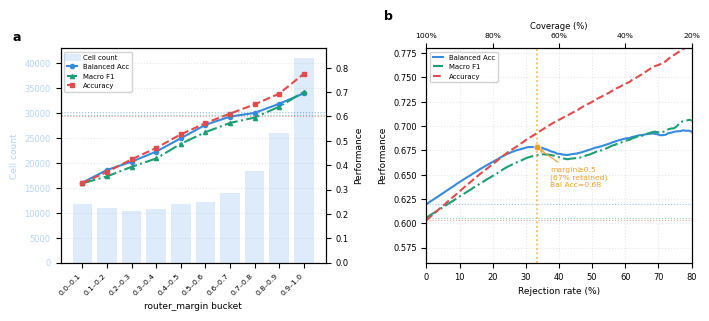

In [15]:
pred_path="/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3_seed42_with_expert_margin/predictions.parquet"
out_path="/hpc/group/jilab/rz179/MorphPT_MOE/results/plots/confidence_reliability_router_margin.pdf"
fig, axes = plot_confidence_reliability(
    pred_path  = pred_path,
    margin_col = "router_margin",
    save_path  = out_path,
)
plt.show()


[router_margin]  167,401 cells  |  21 classes
  Baseline:  Bal Acc=0.62  Macro F1=0.61  Acc=0.60
  threshold≥0.5: cov=66.7%  Bal Acc=0.68  Macro F1=0.67


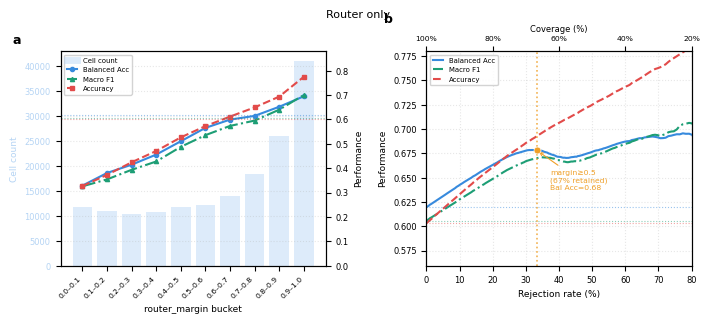

[router_x_expert]  167,401 cells  |  21 classes
  Baseline:  Bal Acc=0.62  Macro F1=0.61  Acc=0.60
  threshold≥0.5: cov=40.6%  Bal Acc=0.71  Macro F1=0.72


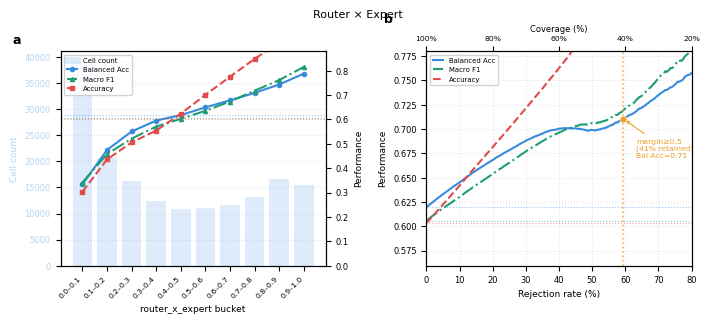

[router_x_maxpe]  167,401 cells  |  21 classes
  Baseline:  Bal Acc=0.62  Macro F1=0.61  Acc=0.60
  threshold≥0.5: cov=49.9%  Bal Acc=0.72  Macro F1=0.72


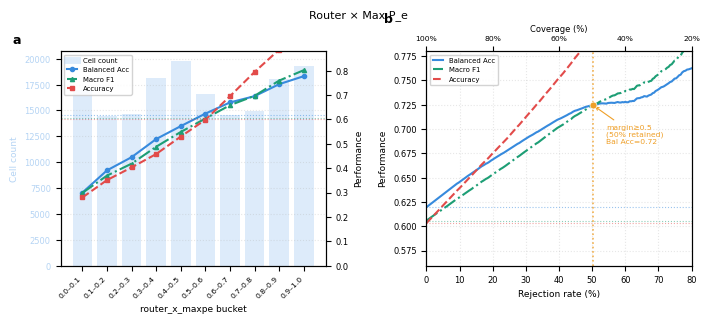

In [16]:
for col, label in [
    ("router_margin",   "Router only"),
    ("router_x_expert", "Router × Expert"),
    ("router_x_maxpe",  "Router × Max P_e"),
]:
    fig, _ = plot_confidence_reliability(
        pred_path  = pred_path,
        margin_col = col,
        title      = label,
    )
    plt.show()

Computing Router margin...
Computing Router × Max P(e)...
Computing Router × Expert M...


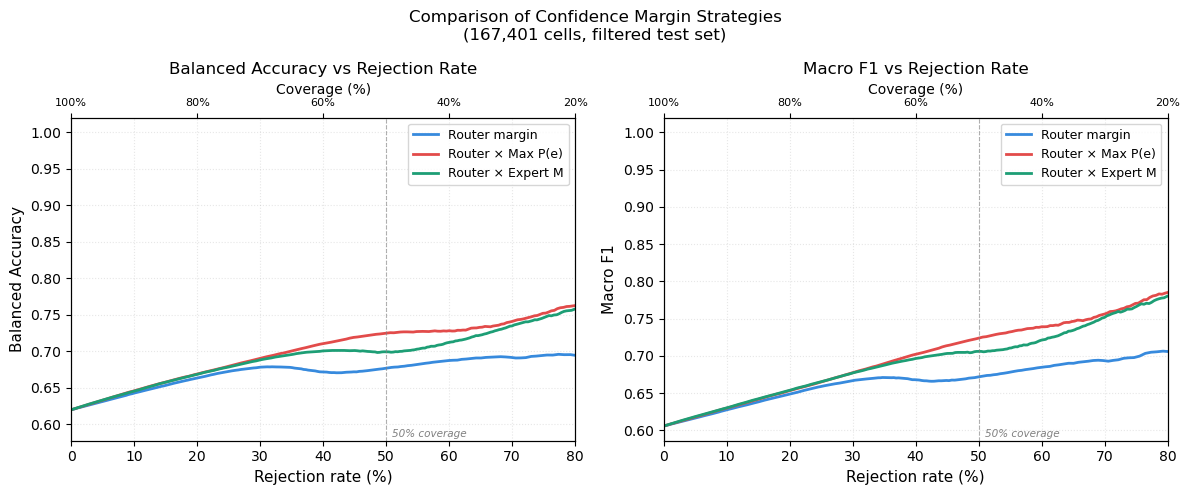


─────────────────────────────────────────────────────────────────
  Margin                   @67% cov   @50% cov   @33% cov
                            Bal Acc    Bal Acc    Bal Acc
─────────────────────────────────────────────────────────────────
  Router margin              0.6783     0.6763     0.6917
  Router × Max P(e)          0.6966     0.7248     0.7344
  Router × Expert M          0.6925     0.6990     0.7266


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRED_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3_seed42_with_expert_margin/predictions.parquet"
N_STEPS   = 200

df = pd.read_parquet(PRED_PATH)
all_classes = sorted(df["label"].unique())

MARGIN_COLS = {
    "Router margin":      ("router_margin",    "#378ADD"),
    "Router × Max P(e)":  ("router_x_maxpe",   "#E24B4A"),
    "Router × Expert M":  ("router_x_expert",  "#1D9E75"),
}

def sweep_coverage(df, margin_col, pred_col="pred_top1", label_col="label"):
    margins = df[margin_col].values
    y_true  = df[label_col].values
    y_pred  = df[pred_col].values
    sort_idx = np.argsort(margins)
    m_s = margins[sort_idx]
    yt_s = y_true[sort_idx]
    yp_s = y_pred[sort_idx]
    thresholds = np.linspace(m_s[0], m_s[-1] * 0.999, N_STEPS)
    rej, bal, f1, acc = [], [], [], []
    for t in thresholds:
        start = int(np.searchsorted(m_s, t, side="left"))
        rem   = len(m_s) - start
        if rem < 50:
            break
        name_to_idx = {n: i for i, n in enumerate(all_classes)}
        ti = np.array([name_to_idx.get(y, -1) for y in yt_s[start:]])
        pi = np.array([name_to_idx.get(y, -1) for y in yp_s[start:]])
        rows = []
        for i, c in enumerate(all_classes):
            tp = int(((ti==i)&(pi==i)).sum())
            fn = int(((ti==i)&(pi!=i)).sum())
            fp = int(((ti!=i)&(pi==i)).sum())
            n  = tp + fn
            if n == 0: continue
            rec = tp / max(tp+fn, 1)
            f1v = 2*(tp/max(tp+fp,1))*rec / max((tp/max(tp+fp,1))+rec, 1e-12)
            rows.append({"rec": rec, "f1": f1v})
        rej.append(100 * (len(df) - rem) / len(df))
        bal.append(float(np.mean([r["rec"] for r in rows])))
        f1.append(float(np.mean([r["f1"] for r in rows])))
        acc.append(float((ti == pi).sum()) / max(len(ti), 1))
    return np.array(rej), np.array(bal), np.array(f1), np.array(acc)

# ── Compute sweeps ────────────────────────────────────────────────────────

results = {}
for name, (col, color) in MARGIN_COLS.items():
    print(f"Computing {name}...")
    rej, bal, f1, acc = sweep_coverage(df, col)
    results[name] = {"rej": rej, "bal": bal, "f1": f1, "acc": acc,
                     "color": color, "col": col}

# ── Plot ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, ylabel in [
    (axes[0], "bal", "Balanced Accuracy"),
    (axes[1], "f1",  "Macro F1"),
]:
    for name, res in results.items():
        ax.plot(res["rej"], res[metric],
                color=res["color"], linewidth=2.0, label=name)

    ax.set_xlabel("Rejection rate (%)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlim(0, 80)
    ax.legend(fontsize=9)
    ax.grid(linestyle=":", alpha=0.3)

    # Coverage top axis
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks([0, 20, 40, 60, 80])
    ax2.set_xticklabels(["100%", "80%", "60%", "40%", "20%"], fontsize=8)
    ax2.set_xlabel("Coverage (%)", fontsize=10, labelpad=3)

    # Reference line at 50% coverage (rejection=50%)
    ax.axvline(50, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(51, ax.get_ylim()[0] + 0.005, "50% coverage",
            fontsize=7.5, color="gray", style="italic")

axes[0].set_title("Balanced Accuracy vs Rejection Rate", fontsize=12)
axes[1].set_title("Macro F1 vs Rejection Rate", fontsize=12)

fig.suptitle("Comparison of Confidence Margin Strategies\n"
             f"({len(df):,} cells, filtered test set)",
             fontsize=12)
plt.tight_layout()
plt.show()

# ── Print at fixed coverages ──────────────────────────────────────────────
print(f"\n{'─'*65}")
print(f"  {'Margin':<22} {'@67% cov':>10} {'@50% cov':>10} {'@33% cov':>10}")
print(f"  {'':22} {'Bal Acc':>10} {'Bal Acc':>10} {'Bal Acc':>10}")
print(f"{'─'*65}")
for name, res in results.items():
    vals = []
    for target_rej in [33, 50, 67]:  # 67/50/33% rejection = 33/50/67% coverage
        idx = np.argmin(np.abs(res["rej"] - target_rej))
        vals.append(res["bal"][idx])
    print(f"  {name:<22} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}")


═════════════════════════════════════════════════════════════════════════════════════
   Threshold  |     Bal     F1   Cov%  |     Bal     F1   Cov%  |     Bal     F1   Cov%
              |         Router margin  |     Router × Max P(e)  |     Router × Expert M
─────────────────────────────────────────────────────────────────────────────────────
  margin≥0.0  |     0.620  0.606 100.0%  |     0.620  0.606 100.0%  |     0.620  0.606 100.0%  |  
  margin≥0.1  |     0.636  0.621  93.0%  |     0.646  0.630  89.9%  |     0.675  0.662  76.6%  |  
  margin≥0.2  |     0.650  0.635  86.4%  |     0.666  0.650  81.2%  |     0.697  0.689  64.2%  |  
  margin≥0.3  |     0.663  0.648  80.3%  |     0.685  0.671  72.5%  |     0.700  0.703  54.5%  |  
  margin≥0.4  |     0.674  0.661  73.8%  |     0.707  0.698  61.7%  |     0.700  0.708  47.1%  |  
  margin≥0.5  |     0.678  0.670  66.7%  |     0.725  0.724  49.9%  |     0.711  0.719  40.6%  |  
  margin≥0.6  |     0.671  0.668  59.5%  |     0.728  0.7

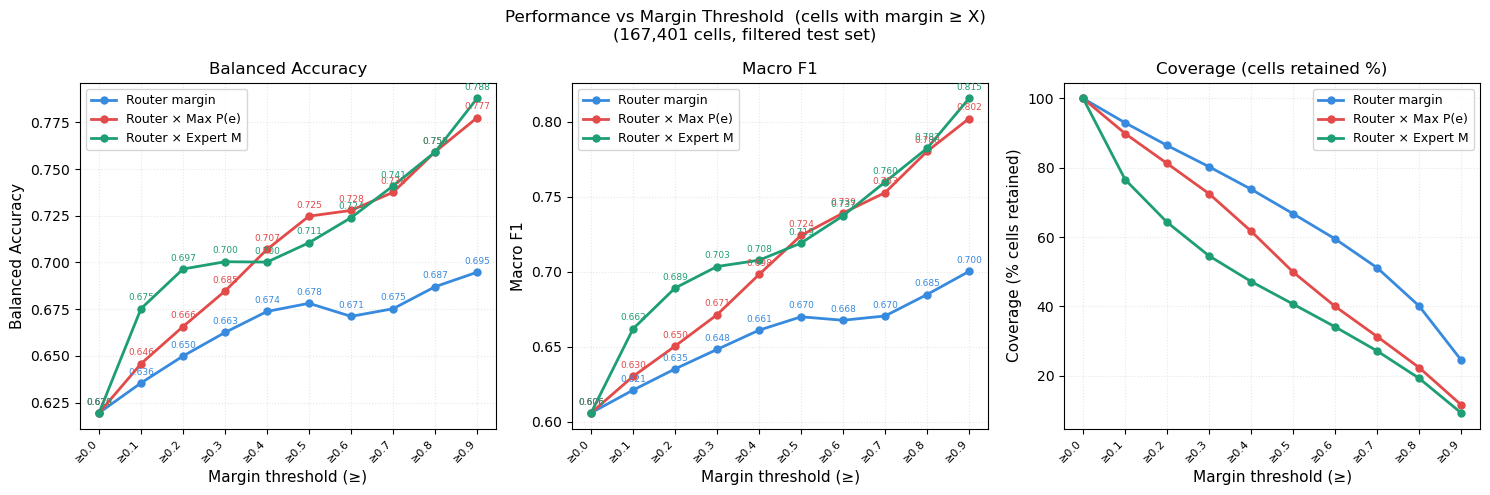

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRED_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3_seed42_with_expert_margin/predictions.parquet"

df = pd.read_parquet(PRED_PATH)
all_classes = sorted(df["label"].unique())

MARGIN_COLS = {
    "Router margin":     ("router_margin",   "#378ADD"),
    "Router × Max P(e)": ("router_x_maxpe",  "#E24B4A"),
    "Router × Expert M": ("router_x_expert", "#1D9E75"),
}

thresholds = np.arange(0.0, 1.0, 0.1)  # 0.0, 0.1, ..., 0.9

def compute_at_threshold(df, margin_col, threshold,
                          pred_col="pred_top1", label_col="label"):
    subset = df[df[margin_col] >= threshold]
    if len(subset) < 50:
        return None
    name_to_idx = {n: i for i, n in enumerate(all_classes)}
    ti = np.array([name_to_idx.get(y, -1) for y in subset[label_col].values])
    pi = np.array([name_to_idx.get(y, -1) for y in subset[pred_col].values])
    rows = []
    for i in range(len(all_classes)):
        tp = int(((ti==i)&(pi==i)).sum())
        fn = int(((ti==i)&(pi!=i)).sum())
        fp = int(((ti!=i)&(pi==i)).sum())
        n  = tp + fn
        if n == 0: continue
        rec = tp / max(tp+fn, 1)
        f1v = 2*(tp/max(tp+fp,1))*rec / max((tp/max(tp+fp,1))+rec, 1e-12)
        rows.append({"rec": rec, "f1": f1v})
    bal = float(np.mean([r["rec"] for r in rows]))
    f1  = float(np.mean([r["f1"]  for r in rows]))
    cov = 100 * len(subset) / len(df)
    return {"bal": bal, "f1": f1, "coverage": cov, "n": len(subset)}

# ── Compute ───────────────────────────────────────────────────────────────

all_results = {}
for name, (col, color) in MARGIN_COLS.items():
    rows = []
    for t in thresholds:
        r = compute_at_threshold(df, col, t)
        if r:
            rows.append({"threshold": t, **r})
    all_results[name] = {"data": pd.DataFrame(rows), "color": color}

# ── Print table ───────────────────────────────────────────────────────────

print(f"\n{'═'*85}")
print(f"  {'Threshold':>10}  |  "
      + "  |  ".join(f"{'Bal':>6} {'F1':>6} {'Cov%':>6}" for _ in MARGIN_COLS))
print(f"  {'':>10}  |  "
      + "  |  ".join(f"{n[:18]:>20}" for n in MARGIN_COLS))
print(f"{'─'*85}")
for t in thresholds:
    row = f"  margin≥{t:.1f}  |  "
    for name, res in all_results.items():
        d = res["data"]
        match = d[d["threshold"] == t]
        if len(match):
            r = match.iloc[0]
            row += f"  {r['bal']:>6.3f} {r['f1']:>6.3f} {r['coverage']:>5.1f}%  |  "
        else:
            row += f"  {'—':>6} {'—':>6} {'—':>6}  |  "
    print(row)

# ── Plot ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, ylabel in [
    (axes[0], "bal",      "Balanced Accuracy"),
    (axes[1], "f1",       "Macro F1"),
    (axes[2], "coverage", "Coverage (% cells retained)"),
]:
    for name, res in all_results.items():
        d = res["data"]
        ax.plot(d["threshold"], d[metric],
                color=res["color"], marker="o", markersize=5,
                linewidth=2.0, label=name)

        # Annotate values at each point
        if metric != "coverage":
            for _, row in d.iterrows():
                ax.annotate(f"{row[metric]:.3f}",
                            (row["threshold"], row[metric]),
                            textcoords="offset points",
                            xytext=(0, 6), ha="center",
                            fontsize=6.5, color=res["color"])

    ax.set_xlabel("Margin threshold (≥)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(thresholds)
    ax.set_xticklabels([f"≥{t:.1f}" for t in thresholds],
                       rotation=45, ha="right", fontsize=8)
    ax.legend(fontsize=9)
    ax.grid(linestyle=":", alpha=0.3)

axes[0].set_title("Balanced Accuracy", fontsize=12)
axes[1].set_title("Macro F1", fontsize=12)
axes[2].set_title("Coverage (cells retained %)", fontsize=12)

fig.suptitle("Performance vs Margin Threshold  (cells with margin ≥ X)\n"
             f"({len(df):,} cells, filtered test set)", fontsize=12)
plt.tight_layout()
plt.show()

## Reliability总图

Loaded 167,401 cells  |  21 classes
Using margin column: router_x_maxpe
Baseline — Bal Acc=0.6294  Macro F1=0.6109  Acc=0.6155

═════════════════════════════════════════════════════════════════
  Bucket distribution  (router_x_maxpe)
═════════════════════════════════════════════════════════════════
  Bucket              N    Pop%   Bal Acc   Macro F1      Acc
  ───────────────────────────────────────────────────────────────
  0.0–0.1        16,962   10.1%    0.3797     0.3283   0.3924
  0.1–0.2        14,563    8.7%    0.4039     0.3751   0.3679
  0.2–0.3        14,705    8.8%    0.4478     0.4236   0.4033
  0.3–0.4        18,137   10.8%    0.5214     0.4908   0.4618
  0.4–0.5        19,724   11.8%    0.5707     0.5462   0.5253
  0.5–0.6        16,398    9.8%    0.6214     0.6014   0.5965
  0.6–0.7        14,580    8.7%    0.6661     0.6545   0.6922
  0.7–0.8        14,936    8.9%    0.6956     0.6966   0.7917
  0.8–0.9        18,200   10.9%    0.7477     0.7621   0.8890
  0.9–1.0     

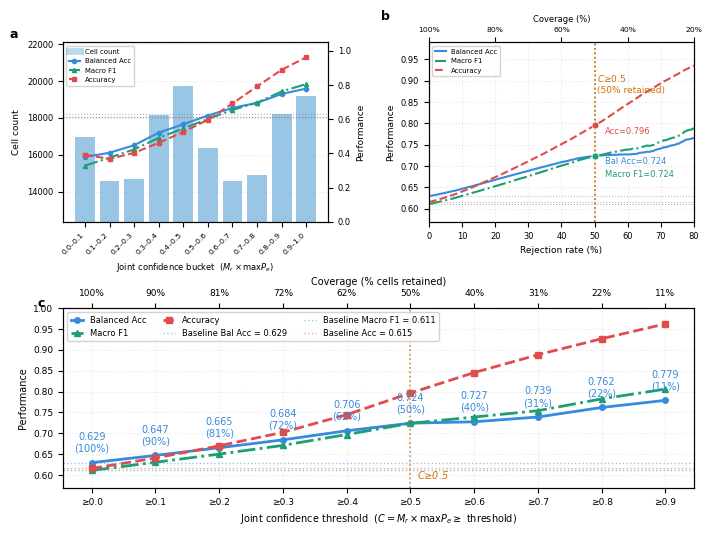

In [1]:
#!/usr/bin/env python3
%matplotlib inline

"""
Confidence & Reliability Figure
=================================
Three-panel figure for Nature submission using router_x_maxpe as joint confidence:
  a. Per-bucket performance bar chart
  b. Coverage-Accuracy curve (continuous)
  c. Performance vs margin threshold (discrete, monotonically increasing)

Output: confidence_reliability.pdf / .png
"""

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

PRED_PATH  = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3_with_expert_margin_with_gate_2_5x/predictions.parquet"
#PRED_PATH  = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3_seed42_with_expert_margin/predictions.parquet"
OUT_PATH   = "confidence_reliability"
MARGIN_COL = "router_x_maxpe"
#PRED_COL   = "pred_top1"
PRED_COL = "pred_soft"
N_STEPS    = 200

# Nature double-column: 180mm = 7.09in
FIG_W = 7.09
FIG_H = 5.5

# Colors
C_BAL = "#378ADD"
C_F1  = "#1D9E75"
C_ACC = "#E24B4A"
C_BAR = "#B5D4F4"
C_THR = "#D4700A"
C_REF = "#888780"


# ── Load ──────────────────────────────────────────────────────────────────

df = pd.read_parquet(PRED_PATH)
all_classes = sorted(df["label"].unique())
N = len(df)
print(f"Loaded {N:,} cells  |  {len(all_classes)} classes")
print(f"Using margin column: {MARGIN_COL}")


def compute_metrics(y_true, y_pred):
    name_to_idx = {n: i for i, n in enumerate(all_classes)}
    ti = np.array([name_to_idx.get(y, -1) for y in y_true])
    pi = np.array([name_to_idx.get(y, -1) for y in y_pred])
    rows = []
    for i in range(len(all_classes)):
        tp = int(((ti==i)&(pi==i)).sum())
        fn = int(((ti==i)&(pi!=i)).sum())
        fp = int(((ti!=i)&(pi==i)).sum())
        n  = tp + fn
        if n == 0: continue
        prec = tp / max(tp+fp, 1)
        rec  = tp / max(tp+fn, 1)
        f1   = 2*prec*rec / max(prec+rec, 1e-12)
        rows.append({"rec": rec, "f1": f1})
    bal = float(np.mean([r["rec"] for r in rows]))
    mf1 = float(np.mean([r["f1"]  for r in rows]))
    acc = float((ti==pi).sum()) / max(len(ti), 1)
    return bal, mf1, acc


# ── Baseline ──────────────────────────────────────────────────────────────

base_bal, base_mf1, base_acc = compute_metrics(
    df["label"].values, df[PRED_COL].values
)
print(f"Baseline — Bal Acc={base_bal:.4f}  Macro F1={base_mf1:.4f}  Acc={base_acc:.4f}")


# ── Panel a: bucket ───────────────────────────────────────────────────────

buckets = [(i/10, (i+1)/10) for i in range(10)]
bin_labels, cells, baccs, macros, accs = [], [], [], [], []

for lo, hi in buckets:
    mask   = (df[MARGIN_COL] >= lo) & (df[MARGIN_COL] < hi)
    subset = df[mask]
    if len(subset) == 0:
        continue
    bal, mf1, acc = compute_metrics(subset["label"].values, subset[PRED_COL].values)
    bin_labels.append(f"{lo:.1f}–{hi:.1f}")
    cells.append(len(subset))
    baccs.append(bal)
    macros.append(mf1)
    accs.append(acc)

print(f"\n{'═'*65}")
print(f"  Bucket distribution  ({MARGIN_COL})")
print(f"{'═'*65}")
print(f"  {'Bucket':<12} {'N':>8} {'Pop%':>7} {'Bal Acc':>9} {'Macro F1':>10} {'Acc':>8}")
print(f"  {'─'*63}")
for label, n, bal, mf1, acc in zip(bin_labels, cells, baccs, macros, accs):
    pct = 100 * n / N
    flag = " ◀" if bal == max(baccs) else ""
    print(f"  {label:<12} {n:>8,} {pct:>6.1f}% {bal:>9.4f} {mf1:>10.4f} {acc:>8.4f}{flag}")
print(f"  {'─'*63}")
print(f"  {'Baseline':<12} {N:>8,} {'100.0%':>7} {base_bal:>9.4f} {base_mf1:>10.4f} {base_acc:>8.4f}")
print(f"{'═'*65}")

# ── Panel b: coverage-accuracy sweep ─────────────────────────────────────

margins  = df[MARGIN_COL].values
y_true   = df["label"].values
y_pred   = df[PRED_COL].values

sort_asc = np.argsort(margins)
m_asc    = margins[sort_asc]
yt_asc   = y_true[sort_asc]
yp_asc   = y_pred[sort_asc]

thresholds_cont = np.linspace(m_asc[0], m_asc[-1] * 0.999, N_STEPS)
cov_rej, cov_bal, cov_f1, cov_acc = [], [], [], []

for t in thresholds_cont:
    start = int(np.searchsorted(m_asc, t, side="left"))
    rem   = len(m_asc) - start
    if rem < 50:
        break
    bal, mf1, acc = compute_metrics(yt_asc[start:], yp_asc[start:])
    cov_rej.append(100 * (N - rem) / N)
    cov_bal.append(bal)
    cov_f1.append(mf1)
    cov_acc.append(acc)

cov_rej = np.array(cov_rej)
cov_bal = np.array(cov_bal)
cov_f1  = np.array(cov_f1)
cov_acc = np.array(cov_acc)

# Reference at threshold=0.5
ref_rej = 100 * (df[MARGIN_COL] < 0.5).mean()
ref_cov = 100 - ref_rej
high    = df[df[MARGIN_COL] >= 0.5]
ref_bal, ref_mf1, ref_acc = compute_metrics(
    high["label"].values, high[PRED_COL].values
)
print(f"Joint margin≥0.5: cov={ref_cov:.1f}%  Bal Acc={ref_bal:.4f}  Macro F1={ref_mf1:.4f}")


# ── Panel c: discrete threshold sweep ────────────────────────────────────

thresholds_disc = np.arange(0.0, 1.0, 0.1)
disc_thr, disc_bal, disc_f1, disc_acc, disc_cov = [], [], [], [], []

for t in thresholds_disc:
    subset = df[df[MARGIN_COL] >= t]
    if len(subset) < 50:
        break
    bal, mf1, acc = compute_metrics(subset["label"].values, subset[PRED_COL].values)
    disc_thr.append(t)
    disc_bal.append(bal)
    disc_f1.append(mf1)
    disc_acc.append(acc)
    disc_cov.append(100 * len(subset) / N)

disc_thr = np.array(disc_thr)
disc_bal = np.array(disc_bal)
disc_f1  = np.array(disc_f1)
disc_acc = np.array(disc_acc)
disc_cov = np.array(disc_cov)


# ── Build figure ──────────────────────────────────────────────────────────

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs  = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.48,
    wspace=0.38,
    left=0.08, right=0.97,
    top=0.92,  bottom=0.11,
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])


# ── Panel a ───────────────────────────────────────────────────────────────

ax_a2 = ax_a.twinx()
ax_a.bar(range(len(bin_labels)), cells,
         color=C_BAR, alpha=0.45, zorder=1)
ax_a2.plot(range(len(bin_labels)), baccs,
           color=C_BAL, marker="o", markersize=3, linewidth=1.5, label="Balanced Acc")
ax_a2.plot(range(len(bin_labels)), macros,
           color=C_F1,  marker="^", markersize=3, linewidth=1.5, linestyle="-.", label="Macro F1")
ax_a2.plot(range(len(bin_labels)), accs,
           color=C_ACC, marker="s", markersize=3, linewidth=1.5, linestyle="--", label="Accuracy")

ax_a2.axhline(base_bal, color=C_BAL, linestyle=":", linewidth=0.8, alpha=0.5)
ax_a2.axhline(base_mf1, color=C_F1,  linestyle=":", linewidth=0.8, alpha=0.5)
ax_a2.axhline(base_acc, color=C_ACC, linestyle=":", linewidth=0.8, alpha=0.5)

ax_a.set_xticks(range(len(bin_labels)))
ax_a.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=5.5)
ax_a.set_xlabel(r"Joint confidence bucket  ($M_r \times \max P_e$)", fontsize=6.0)
ax_a.set_ylabel("Cell count", fontsize=6.5, color="black")
ax_a2.set_ylabel("Performance", fontsize=6.5)
ax_a2.set_ylim(0, 1.05)

bar_bottom = max(0, min(cells) * 0.85)
ax_a.bar(range(len(bin_labels)),
         [c - bar_bottom for c in cells],
         bottom=bar_bottom,
         color="#6AAED6", alpha=0.6, zorder=1)
ax_a.set_ylim(bar_bottom, max(cells) * 1.12)

#ax_a.set_ylim(8000, max(cells) * 1.1)
ax_a.tick_params(axis="y", labelcolor="black", labelsize=6)
ax_a2.tick_params(labelsize=6)
ax_a.tick_params(axis="x", labelsize=5.5)
ax_a.grid(axis="y", linestyle=":", alpha=0.3, zorder=0)

legend_handles = [
    Line2D([0],[0], color="#6AAED6", linewidth=5, alpha=0.45, label="Cell count"),
    Line2D([0],[0], color=C_BAL, linewidth=1.5, marker="o", markersize=3, label="Balanced Acc"),
    Line2D([0],[0], color=C_F1,  linewidth=1.5, marker="^", markersize=3, linestyle="-.", label="Macro F1"),
    Line2D([0],[0], color=C_ACC, linewidth=1.5, marker="s", markersize=3, linestyle="--", label="Accuracy"),
]
ax_a.legend(handles=legend_handles, fontsize=5, loc="upper left",
            framealpha=0.85, handlelength=1.5)
ax_a.text(-0.20, 1.08, "a", transform=ax_a.transAxes,
          fontsize=9, fontweight="bold", va="top", ha="left")


# ── Panel b ───────────────────────────────────────────────────────────────

ax_b.plot(cov_rej, cov_bal, color=C_BAL, linewidth=1.5, label="Balanced Acc")
ax_b.plot(cov_rej, cov_f1,  color=C_F1,  linewidth=1.5, linestyle="-.", label="Macro F1")
ax_b.plot(cov_rej, cov_acc, color=C_ACC, linewidth=1.5, linestyle="--", label="Accuracy")

ax_b.axhline(base_bal, color=C_BAL, linestyle=":", linewidth=0.8, alpha=0.5)
ax_b.axhline(base_mf1, color=C_F1,  linestyle=":", linewidth=0.8, alpha=0.5)
ax_b.axhline(base_acc, color=C_ACC, linestyle=":", linewidth=0.8, alpha=0.5)

ax_b.axvline(ref_rej, color=C_THR, linestyle=":", linewidth=1.2, alpha=0.8)

# 找三条线在 ref_rej 处的值
idx_ref = np.argmin(np.abs(cov_rej - ref_rej))
ref_bal_at = cov_bal[idx_ref]
ref_f1_at  = cov_f1[idx_ref]
ref_acc_at = cov_acc[idx_ref]

ax_b.axvline(ref_rej, color=C_THR, linestyle=":", linewidth=1.2, alpha=0.8)

# 三个交叉点各自标注
ax_b.scatter([ref_rej], [ref_bal_at], color=C_BAL, zorder=5, s=25,
             edgecolors="white", linewidth=0.5)
ax_b.scatter([ref_rej], [ref_f1_at],  color=C_F1,  zorder=5, s=25,
             edgecolors="white", linewidth=0.5)
ax_b.scatter([ref_rej], [ref_acc_at], color=C_ACC, zorder=5, s=25,
             edgecolors="white", linewidth=0.5)

ax_b.annotate(f"Bal Acc={ref_bal_at:.3f}",
              xy=(ref_rej, ref_bal_at),
              xytext=(ref_rej + 3, ref_bal_at - 0.02),
              fontsize=6, color=C_BAL)

ax_b.annotate(f"Macro F1={ref_f1_at:.3f}",
              xy=(ref_rej, ref_f1_at),
              xytext=(ref_rej + 3, ref_f1_at - 0.05),
              fontsize=6, color=C_F1)

ax_b.annotate(f"Acc={ref_acc_at:.3f}",
              xy=(ref_rej, ref_acc_at),
              xytext=(ref_rej + 3, ref_acc_at - 0.02),
              fontsize=6, color=C_ACC)

# threshold label 单独放在竖线顶部
ax_b.text(ref_rej + 0.5, ax_b.get_ylim()[1] * 0.9,
          f"$C$≥0.5\n({ref_cov:.0f}% retained)",
          fontsize=6.5, color=C_THR, va="top")
ax_b.set_xlabel("Rejection rate (%)", fontsize=6.5)
ax_b.set_ylabel("Performance", fontsize=6.5)
ax_b.set_xlim(0, 80)
ax_b.set_ylim(base_bal - 0.06, 0.99)
ax_b.tick_params(labelsize=6)
ax_b.grid(linestyle=":", alpha=0.3)
ax_b.legend(fontsize=5, loc="upper left", framealpha=0.85, handlelength=1.5)

ax_b2 = ax_b.twiny()
ax_b2.set_xlim(ax_b.get_xlim())
ax_b2.set_xticks([0, 20, 40, 60, 80])
ax_b2.set_xticklabels(["100%", "80%", "60%", "40%", "20%"], fontsize=5.5)
ax_b2.set_xlabel("Coverage (%)", fontsize=6.0, labelpad=3)

ax_b.text(-0.18, 1.18, "b", transform=ax_b.transAxes,
          fontsize=9, fontweight="bold", va="top", ha="left")


# ── Panel c ───────────────────────────────────────────────────────────────

ax_c.plot(disc_thr, disc_bal, color=C_BAL, marker="o", markersize=4,
          linewidth=2.0, label="Balanced Acc")
ax_c.plot(disc_thr, disc_f1,  color=C_F1,  marker="^", markersize=4,
          linewidth=2.0, linestyle="-.", label="Macro F1")
ax_c.plot(disc_thr, disc_acc, color=C_ACC, marker="s", markersize=4,
          linewidth=2.0, linestyle="--", label="Accuracy")

# Annotate Bal Acc values
for t, b, c in zip(disc_thr, disc_bal, disc_cov):
    ax_c.annotate(f"{b:.3f}\n({c:.0f}%)",
                  (t, b), textcoords="offset points",
                  xytext=(0, 8), ha="center", fontsize=7,
                  color=C_BAL)

# Baseline reference
ax_c.axhline(base_bal, color=C_BAL, linestyle=":", linewidth=1.0, alpha=0.5,
             label=f"Baseline Bal Acc = {base_bal:.3f}")
ax_c.axhline(base_mf1, color=C_F1,  linestyle=":", linewidth=1.0, alpha=0.5,
             label=f"Baseline Macro F1 = {base_mf1:.3f}")
ax_c.axhline(base_acc, color=C_ACC, linestyle=":", linewidth=1.0, alpha=0.5,
             label=f"Baseline Acc = {base_acc:.3f}")

# Threshold=0.5 marker
ax_c.axvline(0.5, color=C_THR, linestyle=":", linewidth=1.2, alpha=0.8)
ax_c.text(0.51, base_bal - 0.04, "$C$≥0.5", fontsize=7, color=C_THR, style="italic")

ax_c.set_xlabel(r"Joint confidence threshold  ($C = M_r \times \max P_e \geq$ threshold)",
                fontsize=7)
ax_c.set_ylabel("Performance", fontsize=7)
ax_c.set_xticks(disc_thr)
ax_c.set_xticklabels([f"≥{t:.1f}" for t in disc_thr], fontsize=7)
ax_c.set_ylim(base_bal - 0.06, 1.0)
ax_c.tick_params(labelsize=6.5)
ax_c.grid(linestyle=":", alpha=0.3)
ax_c.legend(fontsize=6, loc="upper left", framealpha=0.85,
            ncol=3, handlelength=1.5)

ax_c.text(-0.04, 1.06, "c", transform=ax_c.transAxes,
          fontsize=9, fontweight="bold", va="top", ha="left")

# Secondary x-axis: coverage %
ax_c2 = ax_c.twiny()
ax_c2.set_xlim(ax_c.get_xlim())
ax_c2.set_xticks(disc_thr)
ax_c2.set_xticklabels([f"{c:.0f}%" for c in disc_cov], fontsize=6.5)
ax_c2.set_xlabel("Coverage (% cells retained)", fontsize=7, labelpad=3)


# ── Save ──────────────────────────────────────────────────────────────────

#plt.savefig(f"{OUT_PATH}.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig(f"{OUT_PATH}.png", dpi=200, bbox_inches="tight")
#print(f"Saved: {OUT_PATH}.pdf / .png")
plt.show()

Loading results...
  Loaded ResNet-50: 21 classes
  Loaded Swin-B: 21 classes
  Loaded DINOv2 ViT-B: 21 classes
  Loaded MorphPT MoE: 21 classes
Saved: fig_panel_2x2.pdf
Saved: fig_panel_2x2.png


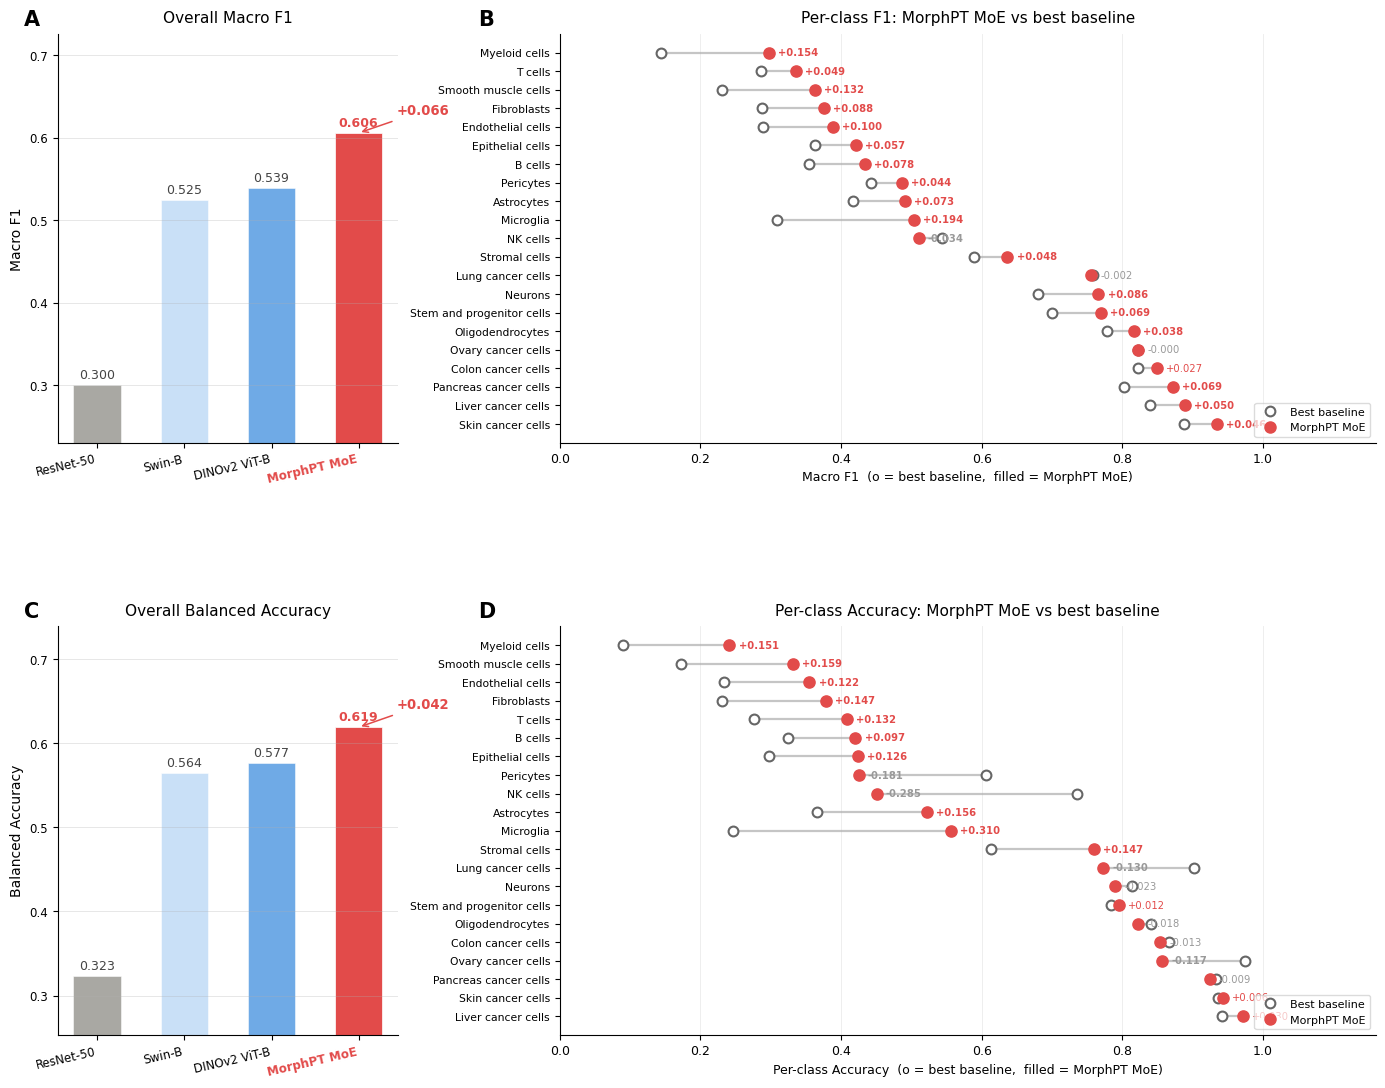

Done.


In [9]:
#!/usr/bin/env python3
"""
Baseline vs MorphPT MoE — 2×2 panel figure  (v3)
==================================================
Layout:
  [A] Overall Macro F1 bar        [B] Per-class F1 dumbbell
  [C] Overall Balanced Acc bar    [D] Per-class Accuracy dumbbell

Dumbbell rows sorted by MorphPT score low→high (hardest on top).
No coarse-group colouring in dumbbell — all y-labels black, neutral grey lines.
Panel D labels everything as "Accuracy" (not Recall).

Usage:
    python compare_baselines_panel.py
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Global style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   8.5,
})

# ── Paths ─────────────────────────────────────────────────────────────────
BASE       = Path("/hpc/group/jilab/rz179/MorphPT_MOE/experiments")
MOE_RESULT = Path(
    "/hpc/group/jilab/rz179/MorphPT_MOE/results/"
    "moe_e2e_nobreast_6clusters_filtered_v3_with_expert_margin_with_gate_2_5x"
)

MODEL_PATHS = {
    "ResNet-50":     BASE / "baseline_resnet50_freeze_2p5x"                  / "per_class.json",
    "Swin-B":        BASE / "baseline_swin_base_patch4_window7_224_2p5x"     / "per_class.json",
    "DINOv2 ViT-B": BASE / "baseline_vit_base_patch16_dinov3.lvd1689m_2p5x" / "per_class.json",
    "MorphPT MoE":  MOE_RESULT / "per_class_top1.json",
}

MODEL_COLORS = {
    "ResNet-50":    "#888780",
    "Swin-B":       "#B5D4F4",
    "DINOv2 ViT-B": "#378ADD",
    "MorphPT MoE":  "#E24B4A",
}

MOE_KEY  = "MorphPT MoE"
BL_EDGE  = "#666666"   # open-circle edge colour for baseline dots
LINE_COL = "#BBBBBB"   # neutral grey dumbbell connecting line

# ── Load ──────────────────────────────────────────────────────────────────
def load_per_class(path):
    rows = json.loads(Path(path).read_text())
    return {r["class"]: r for r in rows}

print("Loading results...")
RESULTS_RAW = {}
for model, path in MODEL_PATHS.items():
    p = Path(path)
    if not p.exists():
        print(f"  WARNING: {p} not found -- skipping {model}")
        continue
    RESULTS_RAW[model] = load_per_class(p)
    print(f"  Loaded {model}: {len(RESULTS_RAW[model])} classes")

models      = list(RESULTS_RAW.keys())
bl_models   = [m for m in models if m != MOE_KEY]
all_classes = sorted(RESULTS_RAW[models[0]].keys())

def get(model, cls, metric):
    return RESULTS_RAW.get(model, {}).get(cls, {}).get(metric, 0.0)

def global_mean(model, metric):
    vals = [get(model, c, metric) for c in all_classes if get(model, c, "n") > 0]
    return float(np.mean(vals)) if vals else 0.0


# ── Figure skeleton ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 13))

gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    width_ratios=[1, 2.4],
    height_ratios=[1, 1],
    hspace=0.45,
    wspace=0.28,
)

ax_f1_bar  = fig.add_subplot(gs[0, 0])   # A
ax_f1_db   = fig.add_subplot(gs[0, 1])   # B
ax_bal_bar = fig.add_subplot(gs[1, 0])   # C
ax_bal_db  = fig.add_subplot(gs[1, 1])   # D

for ax, lbl in zip([ax_f1_bar, ax_f1_db, ax_bal_bar, ax_bal_db],
                   ["A", "B", "C", "D"]):
    ax.text(-0.10, 1.06, lbl, transform=ax.transAxes,
            fontsize=15, fontweight="bold", va="top")


# =========================================================================
# LEFT COLUMN — overall bar chart (one bar per model)
# =========================================================================
def draw_overall_bar(ax, metric, ylabel, title):
    vals = [global_mean(m, metric) for m in models]
    xs   = np.arange(len(models))

    for x, v, m in zip(xs, vals, models):
        alpha = 1.0 if m == MOE_KEY else 0.72
        ax.bar(x, v, 0.55, color=MODEL_COLORS[m], alpha=alpha,
               edgecolor="white", linewidth=0.5)
        ax.text(x, v + 0.004, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9,
                fontweight="bold" if m == MOE_KEY else "normal",
                color=MODEL_COLORS[m] if m == MOE_KEY else "#444444")

    # +Delta annotation above MoE bar
    best_bl = max(global_mean(m, metric) for m in bl_models)
    moe_v   = global_mean(MOE_KEY, metric)
    mi      = models.index(MOE_KEY)
    ax.annotate(
        f"+{moe_v - best_bl:.3f}",
        xy=(mi, moe_v),
        xytext=(mi + 0.44, moe_v + 0.022),
        fontsize=9.5, color="#E24B4A", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.1),
    )

    y_floor = min(vals) - 0.07
    ax.set_ylim(max(0.0, y_floor), min(1.0, max(vals) + 0.12))
    ax.set_xticks(xs)
    ax.set_xticklabels(models, fontsize=8.5, rotation=13, ha="right")
    ax.get_xticklabels()[mi].set_color("#E24B4A")
    ax.get_xticklabels()[mi].set_fontweight("bold")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, pad=8)
    ax.grid(axis="y", alpha=0.3, linewidth=0.7)


draw_overall_bar(ax_f1_bar,  "f1",  "Macro F1",         "Overall Macro F1")
draw_overall_bar(ax_bal_bar, "rec", "Balanced Accuracy", "Overall Balanced Accuracy")


# =========================================================================
# RIGHT COLUMN — dumbbell  (no coarse-group colours, all-black y labels)
# =========================================================================
def draw_dumbbell(ax, metric, xlabel, title):
    cls_data = []
    for cls in all_classes:
        moe_val  = get(MOE_KEY, cls, metric)
        best_val = max(get(m, cls, metric) for m in bl_models)
        cls_data.append({
            "cls":     cls,
            "moe":     moe_val,
            "best_bl": best_val,
            "delta":   moe_val - best_val,
        })

    # Sort by MorphPT score ascending: lowest displayed on top after invert
    cls_data.sort(key=lambda d: d["moe"])
    nc = len(cls_data)

    for i, d in enumerate(cls_data):
        lo = min(d["best_bl"], d["moe"])
        hi = max(d["best_bl"], d["moe"])

        # Connecting line (neutral grey)
        ax.plot([lo, hi], [i, i], color=LINE_COL,
                linewidth=1.6, alpha=0.85, zorder=1)

        # Best-baseline dot: open circle
        ax.scatter(d["best_bl"], i, s=50, zorder=3,
                   facecolors="white", edgecolors=BL_EDGE, linewidths=1.5)

        # MorphPT MoE dot: filled red
        ax.scatter(d["moe"], i, s=65, zorder=4,
                   facecolors=MODEL_COLORS[MOE_KEY],
                   edgecolors=MODEL_COLORS[MOE_KEY])

        # Delta label just right of MoE dot
        sign = "+" if d["delta"] >= 0 else ""
        ax.text(d["moe"] + 0.013, i,
                f"{sign}{d['delta']:.3f}",
                va="center", ha="left", fontsize=7.2,
                color="#E24B4A" if d["delta"] >= 0 else "#999999",
                fontweight="bold" if abs(d["delta"]) > 0.03 else "normal")

    # Y-axis: all black, lowest MorphPT score on top
    ax.set_yticks(range(nc))
    ax.set_yticklabels([d["cls"] for d in cls_data],
                       fontsize=7.8, color="black")
    ax.invert_yaxis()

    # Footer stats embedded in x-label
    n_pos  = sum(1 for d in cls_data if d["delta"] > 0)
    mean_d = np.mean([d["delta"] for d in cls_data])
    ax.set_xlabel(
        f"{xlabel}",
        #f"MorphPT MoE wins {n_pos}/{nc} classes  |  Mean delta = {mean_d:+.3f}",
        fontsize=9,
    )
    ax.set_xlim(0, 1.16)
    ax.set_title(title, fontsize=11, pad=8)
    ax.grid(axis="x", alpha=0.25, linewidth=0.6)

    # Minimal two-item legend
    ax.legend(handles=[
        mlines.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor="white", markeredgecolor=BL_EDGE,
                      markersize=7, markeredgewidth=1.5,
                      label="Best baseline"),
        mlines.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=MODEL_COLORS[MOE_KEY],
                      markeredgecolor=MODEL_COLORS[MOE_KEY],
                      markersize=8, label="MorphPT MoE"),
    ], fontsize=8, loc="lower right", framealpha=0.7)


draw_dumbbell(
    ax_f1_db, "f1",
    xlabel="Macro F1  (o = best baseline,  filled = MorphPT MoE)",
    title="Per-class F1: MorphPT MoE vs best baseline",
)

draw_dumbbell(
    ax_bal_db, "rec",
    xlabel="Per-class Accuracy  (o = best baseline,  filled = MorphPT MoE)",
    title="Per-class Accuracy: MorphPT MoE vs best baseline",
)


# ── Save ──────────────────────────────────────────────────────────────────
for ext in ("pdf", "png"):
    dpi = 300 if ext == "pdf" else 150
    fig.savefig(f"fig_panel_2x2.{ext}", format=ext,
                dpi=dpi, bbox_inches="tight")
    print(f"Saved: fig_panel_2x2.{ext}")

plt.show()
print("Done.")

Loading data...
Data loaded.
         coarse  n_cells  macro_f1  bal_acc
         Cancer    50782    0.8597   0.9328
       Lymphoid    30000    0.4279   0.4433
     Neuroglial    17926    0.6457   0.6711
Stem_Progenitor    10000    0.7699   0.7997
        Stromal     4573    0.6367   0.7638
Tissue_Vascular    54120    0.3995   0.3404
Saved: fig_confusion_panel.pdf
Saved: fig_confusion_panel.png


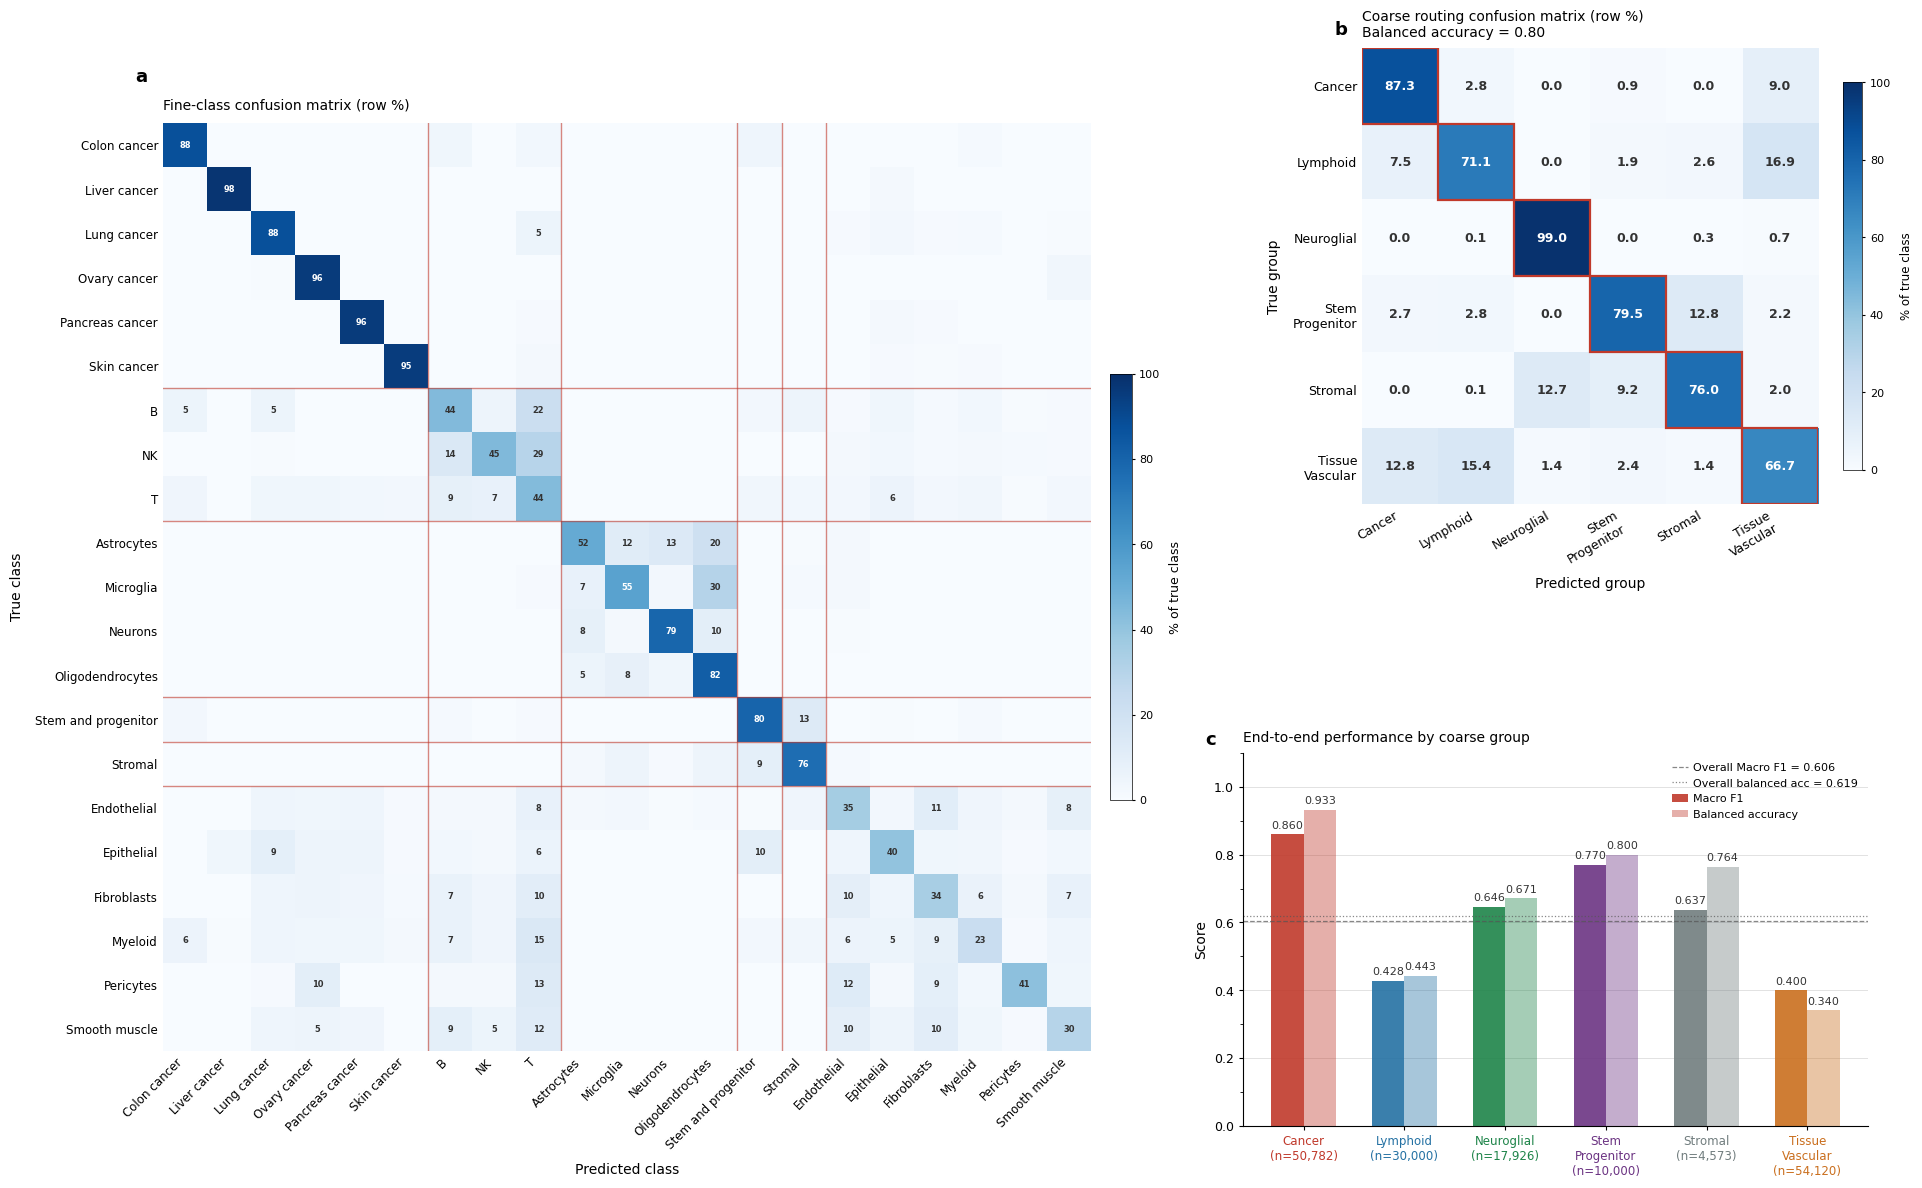

Done.


In [ ]:
#!/usr/bin/env python3
"""
Confusion matrix panel — styled after PreTSA (Genome Biology 2026)
===================================================================
Layout  (1 row × 2 columns):
  a  —  21×21 fine-class confusion matrix
  b  —  6×6 coarse routing confusion matrix      (top-right)
  c  —  coarse-group Macro F1 + Bal Acc bar      (bottom-right)

Style cues from PreTSA fig:
  • lowercase bold panel labels
  • open axes (no top / right spine)
  • white background, minimal / no grid
  • clean sans-serif font, comfortable sizes
  • muted Blues colormap, subdued red boundary lines

Usage:  python confusion_panel.py
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from pathlib import Path

# ── Global style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.size":          10,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.linewidth":     0.8,
    "axes.titlesize":     10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
})

# ── Paths ─────────────────────────────────────────────────────────────────
RESULT_DIR = Path(
    "/hpc/group/jilab/rz179/MorphPT_MOE/results/"
    "moe_e2e_nobreast_6clusters_filtered_v3_with_expert_margin_with_gate_2_5x"
)

# ── Taxonomy ──────────────────────────────────────────────────────────────
FINE_TO_COARSE = {
    "Colon cancer cells":        "Cancer",
    "Liver cancer cells":        "Cancer",
    "Lung cancer cells":         "Cancer",
    "Ovary cancer cells":        "Cancer",
    "Pancreas cancer cells":     "Cancer",
    "Skin cancer cells":         "Cancer",
    "B cells":                   "Lymphoid",
    "NK cells":                  "Lymphoid",
    "T cells":                   "Lymphoid",
    "Astrocytes":                "Neuroglial",
    "Microglia":                 "Neuroglial",
    "Neurons":                   "Neuroglial",
    "Oligodendrocytes":          "Neuroglial",
    "Endothelial cells":         "Tissue_Vascular",
    "Epithelial cells":          "Tissue_Vascular",
    "Fibroblasts":               "Tissue_Vascular",
    "Myeloid cells":             "Tissue_Vascular",
    "Pericytes":                 "Tissue_Vascular",
    "Smooth muscle cells":       "Tissue_Vascular",
    "Stem and progenitor cells": "Stem_Progenitor",
    "Stromal cells":             "Stromal",
}

COARSE_ORDER = [
    "Cancer", "Lymphoid", "Neuroglial",
    "Stem_Progenitor", "Stromal", "Tissue_Vascular",
]

COARSE_COLORS = {
    "Cancer":          "#C0392B",
    "Lymphoid":        "#2471A3",
    "Neuroglial":      "#1E8449",
    "Tissue_Vascular": "#CA6F1E",
    "Stem_Progenitor": "#6C3483",
    "Stromal":         "#717D7E",
}

OVERALL_ROUTER_BAL = 0.80
OVERALL_E2E_MF1    = 0.6055
OVERALL_E2E_BAL    = 0.6191

# ── Load data ─────────────────────────────────────────────────────────────
print("Loading data...")

cm_json     = json.loads((RESULT_DIR / "confusion_matrix_soft.json").read_text())
json_names  = cm_json["class_names"]
cm21_raw    = np.array(cm_json["matrix"], dtype=np.int64)
json_to_idx = {c: i for i, c in enumerate(json_names)}

sorted_fine = []
for coarse in COARSE_ORDER:
    sorted_fine += sorted(c for c in json_names
                          if FINE_TO_COARSE.get(c) == coarse)

sort_idx  = [json_to_idx[c] for c in sorted_fine]
cm21_sort = cm21_raw[np.ix_(sort_idx, sort_idx)]
cm21_pct  = 100 * cm21_sort / cm21_sort.sum(axis=1, keepdims=True).clip(min=1)
n_classes = len(sorted_fine)

boundaries = []
pos = 0
for coarse in COARSE_ORDER:
    pos += sum(1 for c in sorted_fine if FINE_TO_COARSE.get(c) == coarse)
    boundaries.append(pos)

df            = pd.read_parquet(RESULT_DIR / "predictions.parquet")
n_coarse      = len(COARSE_ORDER)
coarse_to_idx = {c: i for i, c in enumerate(COARSE_ORDER)}

cm6 = np.zeros((n_coarse, n_coarse), dtype=np.int64)
for t, p in zip(df["coarse_label"].values, df["router_pred"].values):
    ti, pi = coarse_to_idx.get(t, -1), coarse_to_idx.get(p, -1)
    if ti >= 0 and pi >= 0:
        cm6[ti, pi] += 1
cm6_pct = 100 * cm6 / cm6.sum(axis=1, keepdims=True).clip(min=1)

pc_rows    = json.loads((RESULT_DIR / "per_class_soft.json").read_text())
pc_by_name = {r["class"]: r for r in pc_rows}

coarse_rows = []
for coarse in COARSE_ORDER:
    fines   = [c for c in sorted_fine if FINE_TO_COARSE.get(c) == coarse]
    f1s     = [pc_by_name[c]["f1"]  for c in fines if c in pc_by_name]
    recs    = [pc_by_name[c]["rec"] for c in fines if c in pc_by_name]
    n_cells = int(sum(pc_by_name[c].get("n", 0) for c in fines if c in pc_by_name))
    coarse_rows.append({
        "coarse":   coarse,
        "n_cells":  n_cells,
        "macro_f1": round(float(np.mean(f1s)),  4) if f1s  else 0.0,
        "bal_acc":  round(float(np.mean(recs)), 4) if recs else 0.0,
    })
df_coarse = pd.DataFrame(coarse_rows)
print("Data loaded.")
print(df_coarse.to_string(index=False))


# ═══════════════════════════════════════════════════════════════════════════
# Figure layout
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 14))

outer = gridspec.GridSpec(
    1, 2,
    figure=fig,
    width_ratios=[1.55, 1],
    wspace=0.14,
)

ax_fine = fig.add_subplot(outer[0])

right_gs = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=outer[1],
    hspace=0.60,
    height_ratios=[1.1, 0.9],
)
ax_coarse = fig.add_subplot(right_gs[0])
ax_bar    = fig.add_subplot(right_gs[1])


# ── Panel label helper ────────────────────────────────────────────────────
def panel_label(ax, letter, x=-0.06, y=1.06):
    ax.text(x, y, letter, transform=ax.transAxes,
            fontsize=13, fontweight="bold", va="top", ha="left",
            fontfamily="DejaVu Sans")


# ═══════════════════════════════════════════════════════════════════════════
# Panel a — 21×21 fine confusion matrix
# ═══════════════════════════════════════════════════════════════════════════
panel_label(ax_fine, "a", x=-0.03)

im21 = ax_fine.imshow(cm21_pct, cmap="Blues", vmin=0, vmax=100,
                      aspect="equal", interpolation="nearest")

# Colorbar — slim, right of matrix
cb21 = plt.colorbar(im21, ax=ax_fine, fraction=0.022, pad=0.02, shrink=0.82)
cb21.set_label("% of true class", fontsize=9, labelpad=6)
cb21.ax.tick_params(labelsize=8, length=2)
cb21.outline.set_linewidth(0.5)

# Tick labels — strip " cells" suffix, abbreviate cancer subtypes
short_labels = [
    c.replace(" cells", "").replace(" cancer cells", "\ncancer")
    for c in sorted_fine
]
ax_fine.set_xticks(range(n_classes))
ax_fine.set_yticks(range(n_classes))
ax_fine.set_xticklabels(short_labels, rotation=45, ha="right",
                         fontsize=8.5, va="top")
ax_fine.set_yticklabels(short_labels, fontsize=8.5)

# Cell annotations — only cells > 5 %
for i in range(n_classes):
    for j in range(n_classes):
        v = cm21_pct[i, j]
        if v > 5:
            ax_fine.text(j, i, "{:.0f}".format(v),
                         ha="center", va="center", fontsize=6,
                         color="white" if v > 55 else "#333333",
                         fontweight="bold")

# Coarse boundary lines — muted red, thin
for b in boundaries[:-1]:
    ax_fine.axhline(b - 0.5, color="#C0392B", linewidth=1.0,
                    alpha=0.6, linestyle="-")
    ax_fine.axvline(b - 0.5, color="#C0392B", linewidth=1.0,
                    alpha=0.6, linestyle="-")

# Remove spines around image (imshow generates its own box)
for spine in ax_fine.spines.values():
    spine.set_visible(False)
ax_fine.tick_params(length=0)

ax_fine.set_xlabel("Predicted class", fontsize=10, labelpad=8)
ax_fine.set_ylabel("True class", fontsize=10, labelpad=8)
ax_fine.set_title("Fine-class confusion matrix (row %)", fontsize=10,
                  pad=10, loc="left")


# ═══════════════════════════════════════════════════════════════════════════
# Panel b — 6×6 coarse routing confusion matrix
# ═══════════════════════════════════════════════════════════════════════════
panel_label(ax_coarse, "b")

im6 = ax_coarse.imshow(cm6_pct, cmap="Blues", vmin=0, vmax=100,
                       aspect="equal", interpolation="nearest")

cb6 = plt.colorbar(im6, ax=ax_coarse, fraction=0.040, pad=0.04, shrink=0.85)
cb6.set_label("% of true class", fontsize=8.5, labelpad=6)
cb6.ax.tick_params(labelsize=8, length=2)
cb6.outline.set_linewidth(0.5)

coarse_tick_labels = [c.replace("_", "\n") for c in COARSE_ORDER]
ax_coarse.set_xticks(range(n_coarse))
ax_coarse.set_yticks(range(n_coarse))
ax_coarse.set_xticklabels(coarse_tick_labels, rotation=30, ha="right",
                           fontsize=9)
ax_coarse.set_yticklabels(coarse_tick_labels, fontsize=9)

for i in range(n_coarse):
    for j in range(n_coarse):
        v = cm6_pct[i, j]
        ax_coarse.text(j, i, "{:.1f}".format(v),
                       ha="center", va="center", fontsize=9,
                       color="white" if v > 55 else "#333333",
                       fontweight="bold")

# Diagonal highlight — thin red square border
for k in range(n_coarse):
    ax_coarse.add_patch(plt.Rectangle(
        (k - 0.5, k - 0.5), 1, 1,
        fill=False, edgecolor="#C0392B", linewidth=1.6, zorder=3,
    ))

for spine in ax_coarse.spines.values():
    spine.set_visible(False)
ax_coarse.tick_params(length=0)

ax_coarse.set_xlabel("Predicted group", fontsize=10, labelpad=8)
ax_coarse.set_ylabel("True group", fontsize=10, labelpad=8)
ax_coarse.set_title(
    "Coarse routing confusion matrix (row %)\n"
    "Balanced accuracy = {:.2f}".format(OVERALL_ROUTER_BAL),
    fontsize=10, pad=8, loc="left",
)


# ═══════════════════════════════════════════════════════════════════════════
# Panel c — coarse-group bar chart  (grouped, vertical, no hatch)
# ═══════════════════════════════════════════════════════════════════════════
panel_label(ax_bar, "c")

x_pos  = np.arange(n_coarse)
width  = 0.32
colors = [COARSE_COLORS[c] for c in COARSE_ORDER]

# F1 bars (solid) and Balanced Acc bars (lighter alpha, same colour)
bars_f1 = ax_bar.bar(x_pos - width / 2, df_coarse["macro_f1"], width,
                     color=colors, alpha=0.90, label="Macro F1",
                     linewidth=0)
bars_bal = ax_bar.bar(x_pos + width / 2, df_coarse["bal_acc"], width,
                      color=colors, alpha=0.40, label="Balanced accuracy",
                      linewidth=0)

# Value annotations above bars
for bar in list(bars_f1) + list(bars_bal):
    h = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width() / 2, h + 0.012,
                "{:.3f}".format(h),
                ha="center", va="bottom", fontsize=8, color="#333333")

# Overall reference lines — dashed, subtle
ax_bar.axhline(OVERALL_E2E_MF1, color="#555555", linestyle="--",
               linewidth=0.9, alpha=0.7,
               label="Overall Macro F1 = {:.3f}".format(OVERALL_E2E_MF1))
ax_bar.axhline(OVERALL_E2E_BAL, color="#555555", linestyle=":",
               linewidth=0.9, alpha=0.7,
               label="Overall balanced acc = {:.3f}".format(OVERALL_E2E_BAL))

# x-tick labels coloured by coarse group
bar_xlabels = [
    "{}\n(n={:,})".format(r["coarse"].replace("_", "\n"), r["n_cells"])
    for _, r in df_coarse.iterrows()
]
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(bar_xlabels, fontsize=8.5)
for tick, coarse in zip(ax_bar.get_xticklabels(), COARSE_ORDER):
    tick.set_color(COARSE_COLORS[coarse])

ax_bar.set_ylim(0, 1.10)
ax_bar.set_ylabel("Score", fontsize=10)
ax_bar.set_title(
    "End-to-end performance by coarse group",
    fontsize=10, pad=8, loc="left",
)
ax_bar.yaxis.set_major_locator(ticker.MultipleLsocator(0.2))
ax_bar.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax_bar.tick_params(axis="y", which="minor", length=2)
ax_bar.grid(axis="y", color="#DDDDDD", linewidth=0.6, zorder=0)
ax_bar.set_axisbelow(True)

# Legend — compact, top-right
ax_bar.legend(fontsize=8, loc="upper right", frameon=False, ncol=1,
              handlelength=1.4, handletextpad=0.5)


# ── Save ──────────────────────────────────────────────────────────────────
for ext in ("pdf", "png"):
    dpi = 300 if ext == "pdf" else 150
    fig.savefig("fig_confusion_panel.{}".format(ext), format=ext,
                dpi=dpi, bbox_inches="tight")
    print("Saved: fig_confusion_panel.{}".format(ext))

plt.show()
print("Done.")

Loading predictions...
  167,401 cells loaded

19 cell types after excluding passthrough
                  cls          coarse  router_mean  expert_mean     delta
   Liver cancer cells          Cancer     0.073986     0.006264 -0.228736
   Ovary cancer cells          Cancer     0.006511     0.017376 -0.217624
    Skin cancer cells          Cancer     0.173215     0.032460 -0.202540
    Lung cancer cells          Cancer     0.247611     0.504375  0.269375
   Colon cancer cells          Cancer     0.252680     0.736494  0.501494
Pancreas cancer cells          Cancer     0.077522     0.962610  0.727610
              B cells        Lymphoid     0.183045     0.372903  0.137903
             NK cells        Lymphoid     0.216703     0.383019  0.148019
              T cells        Lymphoid     0.243431     0.448445  0.213445
            Microglia      Neuroglial     0.280410     0.235780  0.000780
     Oligodendrocytes      Neuroglial     0.400962     0.311025  0.076025
              Neurons  

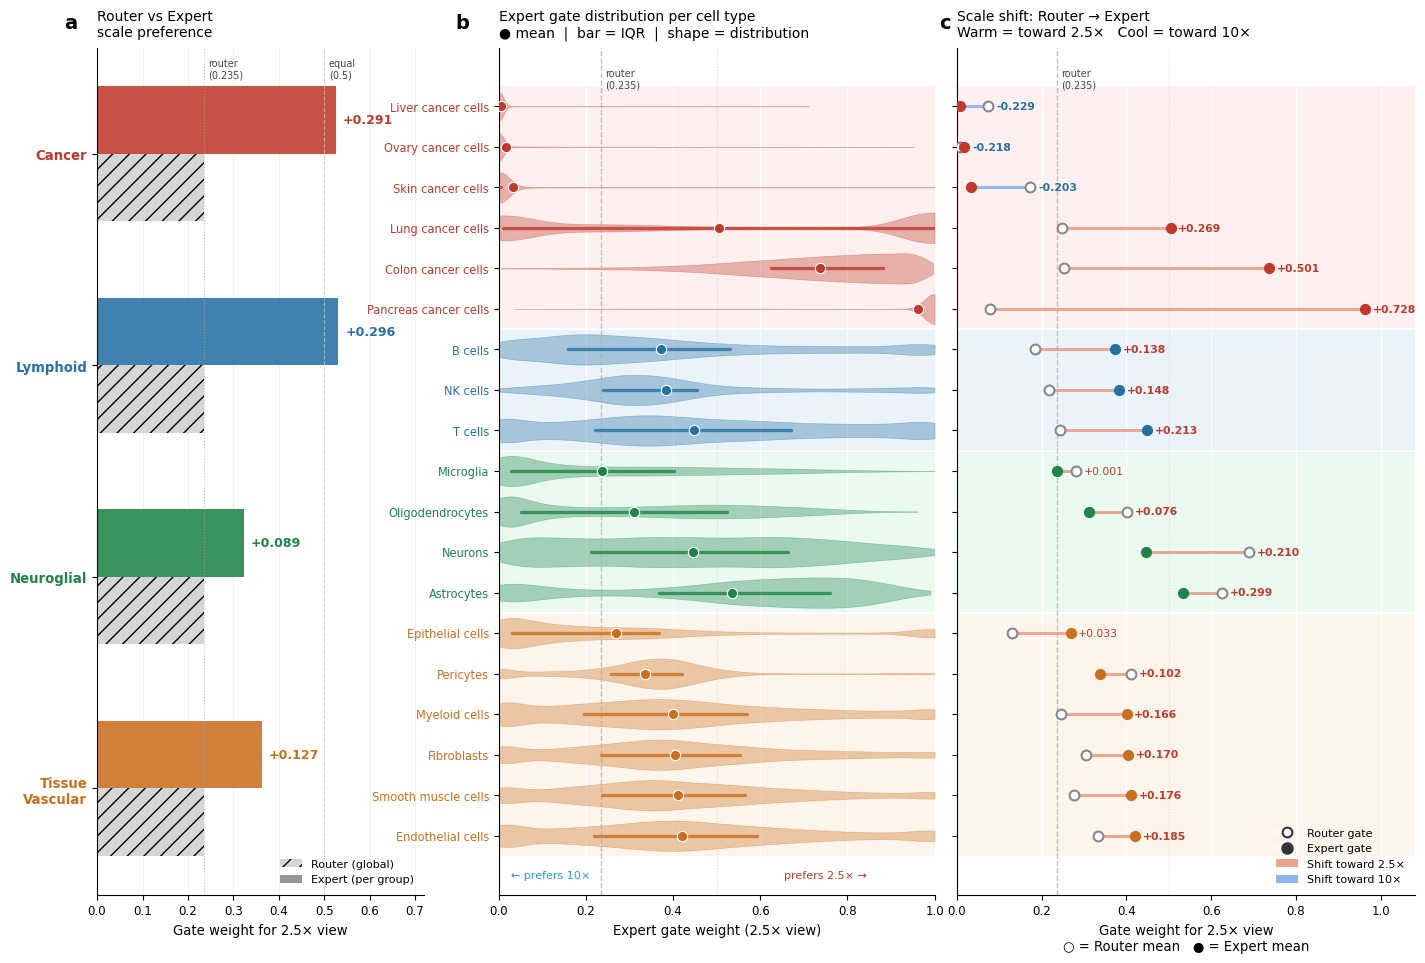

Done.


In [ ]:
#!/usr/bin/env python3
"""
Scale preference panel — v3
============================
Layout:
  Left  (narrow): panel a — coarse bar (Router vs Expert)
  Right (wide):   panel b — violin + dumbbell with shared y-axis

Passthrough classes (Stromal, Stem_Progenitor) excluded from b/c.
Coarse group labels shown as colored background bands on y-axis.

Usage: python scale_preference.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "axes.titlesize":     10,
    "axes.labelsize":     9.5,
    "xtick.labelsize":    8.5,
    "ytick.labelsize":    8.5,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
})

# ── Paths ─────────────────────────────────────────────────────────────────
RESULT_DIR = Path(
    "/hpc/group/jilab/rz179/MorphPT_MOE/results/"
    "moe_e2e_nobreast_6clusters_filtered_v3_with_expert_margin_with_gate_2_5x"
)

# ── Taxonomy ──────────────────────────────────────────────────────────────
FINE_TO_COARSE = {
    "Colon cancer cells":        "Cancer",
    "Liver cancer cells":        "Cancer",
    "Lung cancer cells":         "Cancer",
    "Ovary cancer cells":        "Cancer",
    "Pancreas cancer cells":     "Cancer",
    "Skin cancer cells":         "Cancer",
    "B cells":                   "Lymphoid",
    "NK cells":                  "Lymphoid",
    "T cells":                   "Lymphoid",
    "Astrocytes":                "Neuroglial",
    "Microglia":                 "Neuroglial",
    "Neurons":                   "Neuroglial",
    "Oligodendrocytes":          "Neuroglial",
    "Endothelial cells":         "Tissue_Vascular",
    "Epithelial cells":          "Tissue_Vascular",
    "Fibroblasts":               "Tissue_Vascular",
    "Myeloid cells":             "Tissue_Vascular",
    "Pericytes":                 "Tissue_Vascular",
    "Smooth muscle cells":       "Tissue_Vascular",
    "Stem and progenitor cells": "Stem_Progenitor",
    "Stromal cells":             "Stromal",
}

COARSE_ORDER = [
    "Cancer", "Lymphoid", "Neuroglial", "Tissue_Vascular",
]   # Passthrough excluded

COARSE_COLORS = {
    "Cancer":          "#C0392B",
    "Lymphoid":        "#2471A3",
    "Neuroglial":      "#1E8449",
    "Tissue_Vascular": "#CA6F1E",
}

COARSE_BG = {
    "Cancer":          "#FDF0EF",
    "Lymphoid":        "#EBF3FA",
    "Neuroglial":      "#EAFAF1",
    "Tissue_Vascular": "#FDF5EC",
}

PASSTHROUGH      = {"Stromal", "Stem_Progenitor"}
ROUTER_GATE_2_5X = 0.235

EXPERT_GATE_COARSE = {
    "Cancer":          0.526,
    "Lymphoid":        0.531,
    "Neuroglial":      0.324,
    "Tissue_Vascular": 0.362,
}

# ── Load ──────────────────────────────────────────────────────────────────
print("Loading predictions...")
df = pd.read_parquet(RESULT_DIR / "predictions.parquet")
print(f"  {len(df):,} cells loaded")

# ── Per-fine-class stats (exclude passthrough) ────────────────────────────
fine_stats = []
for cls, coarse in FINE_TO_COARSE.items():
    if coarse in PASSTHROUGH:
        continue
    sub   = df[df["label"] == cls]
    valid = sub["expert_gate_2_5x"].dropna()
    if len(valid) < 20:
        continue
    fine_stats.append({
        "cls":         cls,
        "coarse":      coarse,
        "router_mean": sub["gate_2_5x"].mean(),
        "expert_mean": valid.mean(),
        "expert_vals": valid.values,
        "delta":       valid.mean() - ROUTER_GATE_2_5X,
    })

df_fine = pd.DataFrame(fine_stats)

# Sort: by coarse group order, within group by expert_mean ascending
coarse_rank = {c: i for i, c in enumerate(COARSE_ORDER)}
df_fine["_cr"] = df_fine["coarse"].map(coarse_rank)
df_fine = df_fine.sort_values(
    ["_cr", "expert_mean"], ascending=[True, True]
).reset_index(drop=True)
df_fine.drop(columns=["_cr"], inplace=True)

n_rows = len(df_fine)

# Coarse group y-ranges
group_ranges = {}
for coarse in COARSE_ORDER:
    idxs = df_fine.index[df_fine["coarse"] == coarse].tolist()
    if idxs:
        group_ranges[coarse] = (min(idxs), max(idxs))

print(f"\n{n_rows} cell types after excluding passthrough")
print(df_fine[["cls", "coarse", "router_mean", "expert_mean", "delta"]].to_string(index=False))


# ═══════════════════════════════════════════════════════════════════════════
# Figure layout: left narrow (panel a) + right wide (panels b+c)
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(17, 11))

outer = gridspec.GridSpec(
    1, 2,
    figure=fig,
    width_ratios=[1, 2.8],
    wspace=0.12,
)

ax_a = fig.add_subplot(outer[0])

right_gs = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=outer[1],
    wspace=0.05,
    width_ratios=[1, 1.05],
)
ax_b = fig.add_subplot(right_gs[0])
ax_c = fig.add_subplot(right_gs[1], sharey=ax_b)

# Panel labels
for ax, lbl, xoff in zip(
    [ax_a, ax_b, ax_c], ["a", "b", "c"], [-0.10, -0.10, -0.04]
):
    ax.text(xoff, 1.04, lbl, transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top")


# ═══════════════════════════════════════════════════════════════════════════
# Panel a — Coarse Router vs Expert bar
# ═══════════════════════════════════════════════════════════════════════════
n_groups = len(COARSE_ORDER)
x  = np.arange(n_groups)
bw = 0.32

# Router bars
ax_a.barh(x + bw / 2, [ROUTER_GATE_2_5X] * n_groups, bw,
          color="#CCCCCC", alpha=0.8, hatch="//", linewidth=0,
          label="Router (global = {:.3f})".format(ROUTER_GATE_2_5X))

# Expert bars
for i, coarse in enumerate(COARSE_ORDER):
    ev    = EXPERT_GATE_COARSE[coarse]
    color = COARSE_COLORS[coarse]
    ax_a.barh(x[i] - bw / 2, ev, bw,
              color=color, alpha=0.88, linewidth=0)
    delta = ev - ROUTER_GATE_2_5X
    ax_a.text(ev + 0.015, x[i] - bw / 2,
              "{:+.3f}".format(delta),
              va="center", fontsize=9,
              color=color, fontweight="bold")

# Reference line
ax_a.axvline(0.5, color="#CCCCCC", linewidth=0.8,
             linestyle="--", alpha=0.7)
ax_a.axvline(ROUTER_GATE_2_5X, color="#AAAAAA", linewidth=0.8,
             linestyle=":", alpha=0.7)

ax_a.set_yticks(x)
ax_a.set_yticklabels([c.replace("_", "\n") for c in COARSE_ORDER],
                      fontsize=9.5)
for tick, coarse in zip(ax_a.get_yticklabels(), COARSE_ORDER):
    tick.set_color(COARSE_COLORS[coarse])
    tick.set_fontweight("bold")

ax_a.set_xlim(0, 0.72)
ax_a.set_xlabel("Gate weight for 2.5× view", fontsize=9.5)
ax_a.set_title(
    "Router vs Expert\nscale preference",
    fontsize=10, pad=8, loc="left",
)
ax_a.invert_yaxis()
ax_a.grid(axis="x", color="#EEEEEE", linewidth=0.6, zorder=0)
ax_a.set_axisbelow(True)

ax_a.text(0.5 + 0.01, -0.35, "equal\n(0.5)", fontsize=7, color="#444444", va="bottom")
ax_a.text(ROUTER_GATE_2_5X + 0.01, -0.35, "router\n(0.235)", fontsize=7, color="#444444", va="bottom")

ax_a.legend(handles=[
    mpatches.Patch(facecolor="#CCCCCC", alpha=0.8, hatch="//",
                   label="Router (global)"),
    mpatches.Patch(facecolor="#888888", alpha=0.88,
                   label="Expert (per group)"),
], fontsize=8, loc="lower right", frameon=False)


# ═══════════════════════════════════════════════════════════════════════════
# Shared background bands for coarse groups (drawn on both b and c)
# ═══════════════════════════════════════════════════════════════════════════
def draw_group_bands(ax):
    for coarse, (i_start, i_end) in group_ranges.items():
        ax.axhspan(i_start - 0.5, i_end + 0.5,
                   facecolor=COARSE_BG[coarse], alpha=1.0, zorder=0)
        # Separator line between groups
        if i_end < n_rows - 1:
            ax.axhline(i_end + 0.5, color="white",
                       linewidth=1.5, zorder=1)

    # Coarse group labels on left of ax_b only (handled separately)


# ═══════════════════════════════════════════════════════════════════════════
# Panel b — Violin
# ═══════════════════════════════════════════════════════════════════════════
draw_group_bands(ax_b)

ax_b.axvline(ROUTER_GATE_2_5X, color="#AAAAAA", linewidth=1.0,
             linestyle="--", alpha=0.7, zorder=2)
ax_b.axvline(0.5, color="#CCCCCC", linewidth=0.8,
             linestyle=":", alpha=0.6, zorder=2)

for i, row in df_fine.iterrows():
    color = COARSE_COLORS[row["coarse"]]
    vals  = row["expert_vals"]

    # Violin
    parts = ax_b.violinplot(
        [vals], positions=[i], vert=False,
        widths=0.75, showmedians=False, showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.35)
        pc.set_edgecolor(color)
        pc.set_linewidth(0.5)

    # IQR
    q25, q75 = np.percentile(vals, [25, 75])
    ax_b.plot([q25, q75], [i, i], color=color,
              linewidth=2.4, alpha=0.8, zorder=3,
              solid_capstyle="round")

    # Mean dot
    ax_b.scatter(row["expert_mean"], i, color=color,
                 s=55, zorder=4, edgecolors="white", linewidths=0.8)



ax_b.set_yticks(range(n_rows))
ax_b.set_yticklabels(df_fine["cls"].tolist(), fontsize=8.2)
for tick, (_, row) in zip(ax_b.get_yticklabels(), df_fine.iterrows()):
    tick.set_color(COARSE_COLORS[row["coarse"]])
ax_b.invert_yaxis()

ax_b.set_xlim(0.0, 1.0)
ax_b.set_xlabel("Expert gate weight (2.5× view)", fontsize=9.5)
ax_b.set_title(
    "Expert gate distribution per cell type\n"
    "● mean  |  bar = IQR  |  shape = distribution",
    fontsize=10, pad=8, loc="left",
)
ax_b.grid(axis="x", color="white", linewidth=0.8, zorder=1)
ax_b.set_axisbelow(True)

ax_b.text(0.12, n_rows + 0.1, "← prefers 10×",
          fontsize=8, color="#2196F3", ha="center", va="bottom")
ax_b.text(0.75, n_rows + 0.1, "prefers 2.5× →",
          fontsize=8, color="#C0392B", ha="center", va="bottom")
ax_b.text(ROUTER_GATE_2_5X + 0.01, -0.95, "router\n(0.235)",
          fontsize=7, color="#444444", va="top")


# ═══════════════════════════════════════════════════════════════════════════
# Panel c — Dumbbell shift
# ═══════════════════════════════════════════════════════════════════════════
draw_group_bands(ax_c)

ax_c.axvline(ROUTER_GATE_2_5X, color="#AAAAAA", linewidth=1.0,
             linestyle="--", alpha=0.7, zorder=2)
ax_c.axvline(0.5, color="#CCCCCC", linewidth=0.8,
             linestyle=":", alpha=0.6, zorder=2)
height
for i, row in df_fine.iterrows():
    color = COARSE_COLORS[row["coarse"]]
    r_val = row["router_mean"]
    e_val = row["expert_mean"]
    delta = row["delta"]

    lo = min(r_val, e_val)
    hi = max(r_val, e_val)

    # Line color: warm = shift toward 2.5x, cool = shift toward 10x
    lc = "#E8957A" if delta > 0 else "#7AAAE8"
    ax_c.plot([lo, hi], [i, i], color=lc,
              linewidth=2.2, alpha=0.8, zorder=2,
              solid_capstyle="round")

    # Router dot
    ax_c.scatter(r_val, i, s=50, zorder=3,
                 facecolors="white", edgecolors="#888888",
                 linewidths=1.5)

    # Expert dot
    ax_c.scatter(e_val, i, s=50, zorder=3,
                 facecolors=color, edgecolors=color)

    # Delta label
    sign = "+" if delta >= 0 else ""
    ax_c.text(hi + 0.018, i,
              "{}{:.3f}".format(sign, delta),
              va="center", ha="left", fontsize=7.8,
              color="#C0392B" if delta > 0 else "#2471A3",
              fontweight="bold" if abs(delta) > 0.05 else "normal")

plt.setp(ax_c.get_yticklabels(), visible=False)

ax_c.set_xlim(0.0, 1.08)
ax_c.set_xlabel(
    "Gate weight for 2.5× view\n"
    "○ = Router mean   ● = Expert mean",
    fontsize=9.5,
)
ax_c.set_title(
    "Scale shift: Router → Expert\n"
    "Warm = toward 2.5×   Cool = toward 10×",
    fontsize=10, pad=8, loc="left",
)
ax_c.grid(axis="x", color="white", linewidth=0.8, zorder=1)
ax_c.set_axisbelow(True)

ax_c.text(ROUTER_GATE_2_5X + 0.01, -0.95, "router\n(0.235)",
          fontsize=7, color="#444444", va="top")

ax_c.legend(handles=[
    mlines.Line2D([0], [0], marker="o", color="w",
                  markerfacecolor="white", markeredgecolor="#333333",
                  markersize=7, markeredgewidth=1.5,
                  label="Router gate"),
    mlines.Line2D([0], [0], marker="o", color="w",
                  markerfacecolor="#333333", markeredgecolor="#333333",
                  markersize=8, label="Expert gate"),
    mpatches.Patch(facecolor="#E8957A", alpha=0.85,
                   label="Shift toward 2.5×"),
    mpatches.Patch(facecolor="#7AAAE8", alpha=0.85,
                   label="Shift toward 10×"),
], fontsize=8, loc="lower right", frameon=False)


# ── Save ──────────────────────────────────────────────────────────────────
for ext in ("pdf", "png"):
    dpi = 300 if ext == "pdf" else 150
    fig.savefig("fig_scale_panel.{}".format(ext), format=ext,
                dpi=dpi, bbox_inches="tight")
    print("Saved: fig_scale_panel.{}".format(ext))

plt.show()
print("Done.")

Loading performance data...
  Loaded ResNet-50: 21 classes
  Loaded Swin-B: 21 classes
  Loaded DINOv2 ViT-B: 21 classes
  Loaded MorphPT MoE: 21 classes
Loading confusion data...
Data loaded.
Saved: fig2_performance_analysis.pdf
Saved: fig2_performance_analysis.png


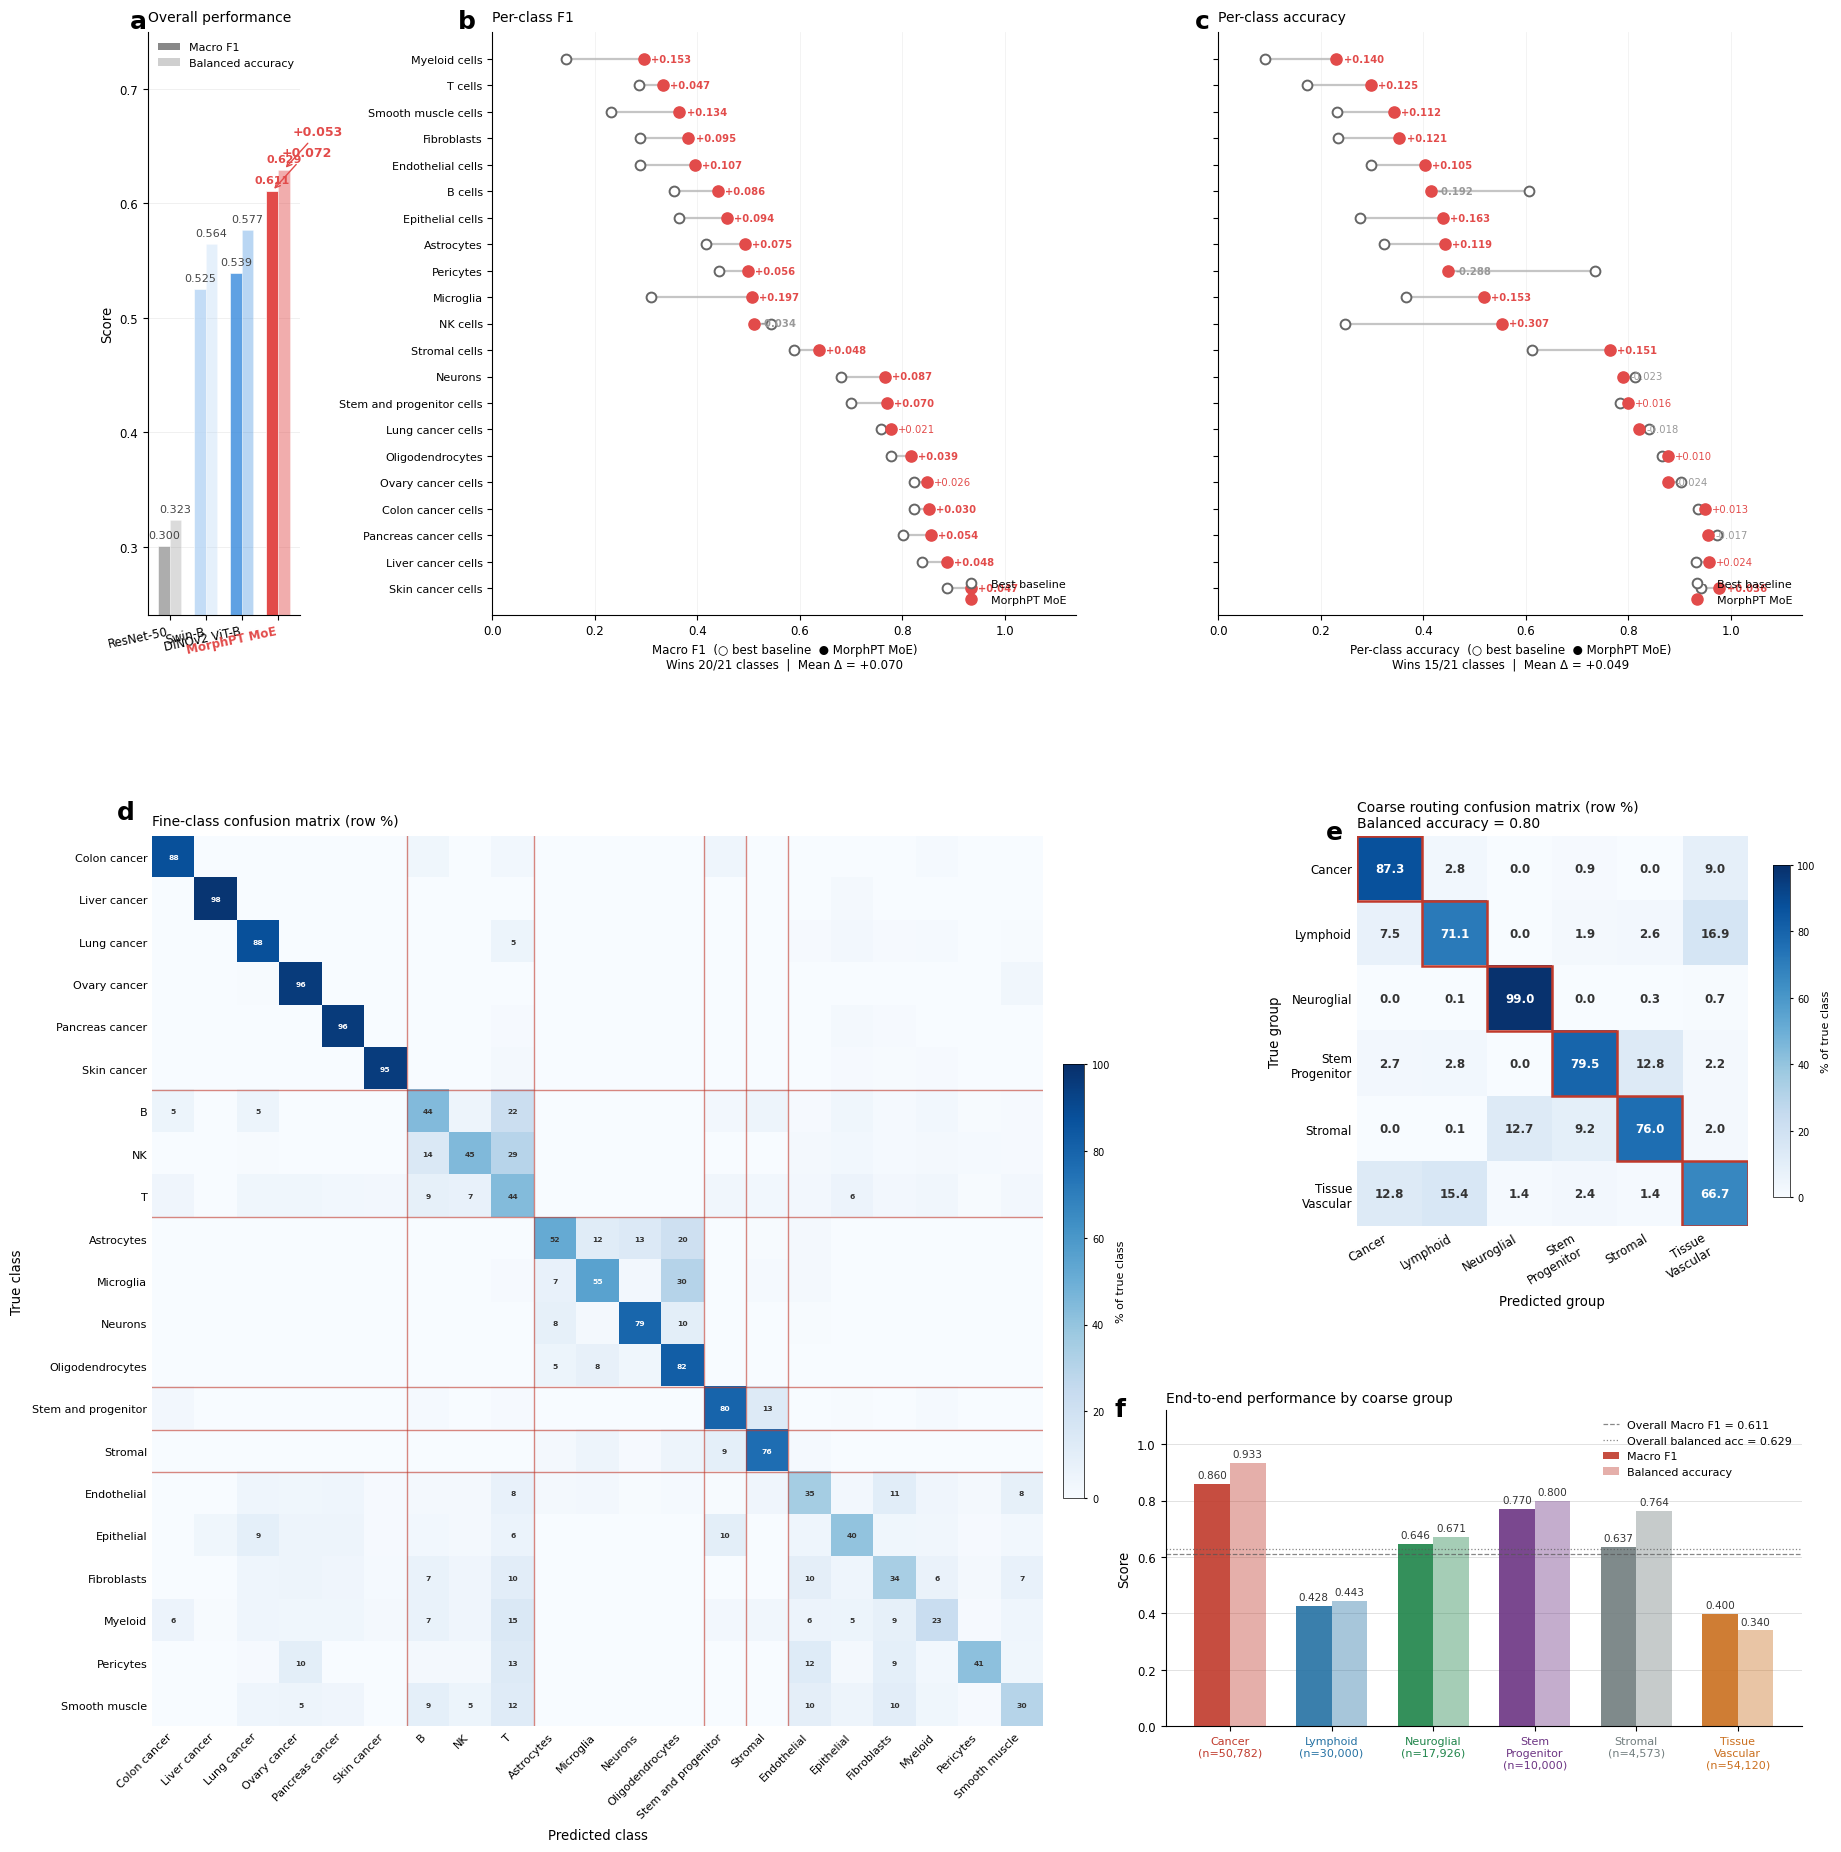

Done.


In [ ]:
#!/usr/bin/env python3
"""
Fig 2 — Performance & Analysis  (2 rows × 3 cols)
===================================================
Row 1 — Baseline comparison:
  a: Combined Macro F1 + Balanced Acc bar (4 models)
  b: Per-class F1 dumbbell
  c: Per-class Accuracy dumbbell

Row 2 — Confusion matrices & coarse summary:
  d: 21×21 fine-class confusion matrix
  e: 6×6 coarse routing confusion matrix
  f: Coarse-group Macro F1 + Balanced Acc bar

Usage: python fig2_performance_analysis.py
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from pathlib import Path

# ── Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "axes.titlesize":     10,
    "axes.labelsize":     9.5,
    "xtick.labelsize":    8.5,
    "ytick.labelsize":    8.5,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
})

# ── Paths ─────────────────────────────────────────────────────────────────
BASE       = Path("/hpc/group/jilab/rz179/MorphPT_MOE/experiments")
MOE_RESULT = Path(
    "/hpc/group/jilab/rz179/MorphPT_MOE/results/"
    "moe_e2e_nobreast_6clusters_filtered_v3_with_expert_margin_with_gate_2_5x"
)

MODEL_PATHS = {
    "ResNet-50":    BASE / "baseline_resnet50_freeze_2p5x"                  / "per_class.json",
    "Swin-B":       BASE / "baseline_swin_base_patch4_window7_224_2p5x"     / "per_class.json",
    "DINOv2 ViT-B": BASE / "baseline_vit_base_patch16_dinov3.lvd1689m_2p5x" / "per_class.json",
    "MorphPT MoE":  MOE_RESULT / "per_class_soft.json",
}

MODEL_COLORS = {
    "ResNet-50":    "#999999",
    "Swin-B":       "#B5D4F4",
    "DINOv2 ViT-B": "#378ADD",
    "MorphPT MoE":  "#E24B4A",
}

MOE_KEY  = "MorphPT MoE"
BL_EDGE  = "#666666"
LINE_COL = "#BBBBBB"

# ── Taxonomy ──────────────────────────────────────────────────────────────
FINE_TO_COARSE = {
    "Colon cancer cells":        "Cancer",
    "Liver cancer cells":        "Cancer",
    "Lung cancer cells":         "Cancer",
    "Ovary cancer cells":        "Cancer",
    "Pancreas cancer cells":     "Cancer",
    "Skin cancer cells":         "Cancer",
    "B cells":                   "Lymphoid",
    "NK cells":                  "Lymphoid",
    "T cells":                   "Lymphoid",
    "Astrocytes":                "Neuroglial",
    "Microglia":                 "Neuroglial",
    "Neurons":                   "Neuroglial",
    "Oligodendrocytes":          "Neuroglial",
    "Endothelial cells":         "Tissue_Vascular",
    "Epithelial cells":          "Tissue_Vascular",
    "Fibroblasts":               "Tissue_Vascular",
    "Myeloid cells":             "Tissue_Vascular",
    "Pericytes":                 "Tissue_Vascular",
    "Smooth muscle cells":       "Tissue_Vascular",
    "Stem and progenitor cells": "Stem_Progenitor",
    "Stromal cells":             "Stromal",
}

COARSE_ORDER = [
    "Cancer", "Lymphoid", "Neuroglial",
    "Stem_Progenitor", "Stromal", "Tissue_Vascular",
]

COARSE_COLORS = {
    "Cancer":          "#C0392B",
    "Lymphoid":        "#2471A3",
    "Neuroglial":      "#1E8449",
    "Tissue_Vascular": "#CA6F1E",
    "Stem_Progenitor": "#6C3483",
    "Stromal":         "#717D7E",
}

OVERALL_ROUTER_BAL = 0.80
OVERALL_E2E_MF1    = 0.6109
OVERALL_E2E_BAL    = 0.6294

# ── Load performance data ─────────────────────────────────────────────────
def load_per_class(path):
    rows = json.loads(Path(path).read_text())
    return {r["class"]: r for r in rows}

print("Loading performance data...")
RESULTS = {}
for model, path in MODEL_PATHS.items():
    p = Path(path)
    if not p.exists():
        print(f"  WARNING: {p} not found")
        continue
    RESULTS[model] = load_per_class(p)
    print(f"  Loaded {model}: {len(RESULTS[model])} classes")

models    = list(RESULTS.keys())
bl_models = [m for m in models if m != MOE_KEY]
all_classes = sorted(RESULTS[models[0]].keys())

def get(model, cls, metric):
    return RESULTS.get(model, {}).get(cls, {}).get(metric, 0.0)

def global_mean(model, metric):
    vals = [get(model, c, metric) for c in all_classes
            if get(model, c, "n") > 0]
    return float(np.mean(vals)) if vals else 0.0

# ── Load confusion data ───────────────────────────────────────────────────
print("Loading confusion data...")
cm_json     = json.loads((MOE_RESULT / "confusion_matrix_soft.json").read_text())
json_names  = cm_json["class_names"]
cm21_raw    = np.array(cm_json["matrix"], dtype=np.int64)
json_to_idx = {c: i for i, c in enumerate(json_names)}

sorted_fine = []
for coarse in COARSE_ORDER:
    sorted_fine += sorted(c for c in json_names
                          if FINE_TO_COARSE.get(c) == coarse)

sort_idx  = [json_to_idx[c] for c in sorted_fine]
cm21_sort = cm21_raw[np.ix_(sort_idx, sort_idx)]
cm21_pct  = 100 * cm21_sort / cm21_sort.sum(axis=1, keepdims=True).clip(min=1)
n_fine    = len(sorted_fine)

boundaries = []
pos = 0
for coarse in COARSE_ORDER:
    pos += sum(1 for c in sorted_fine if FINE_TO_COARSE.get(c) == coarse)
    boundaries.append(pos)

df          = pd.read_parquet(MOE_RESULT / "predictions.parquet")
n_coarse    = len(COARSE_ORDER)
c_to_idx    = {c: i for i, c in enumerate(COARSE_ORDER)}

cm6 = np.zeros((n_coarse, n_coarse), dtype=np.int64)
for t, p in zip(df["coarse_label"].values, df["router_pred"].values):
    ti, pi = c_to_idx.get(t, -1), c_to_idx.get(p, -1)
    if ti >= 0 and pi >= 0:
        cm6[ti, pi] += 1
cm6_pct = 100 * cm6 / cm6.sum(axis=1, keepdims=True).clip(min=1)

pc_rows    = json.loads((MOE_RESULT / "per_class_soft.json").read_text())
pc_by_name = {r["class"]: r for r in pc_rows}

coarse_rows = []
for coarse in COARSE_ORDER:
    fines   = [c for c in sorted_fine if FINE_TO_COARSE.get(c) == coarse]
    f1s     = [pc_by_name[c]["f1"]  for c in fines if c in pc_by_name]
    recs    = [pc_by_name[c]["rec"] for c in fines if c in pc_by_name]
    n_cells = int(sum(pc_by_name[c].get("n", 0) for c in fines if c in pc_by_name))
    coarse_rows.append({
        "coarse":   coarse,
        "n_cells":  n_cells,
        "macro_f1": round(float(np.mean(f1s)),  4) if f1s  else 0.0,
        "bal_acc":  round(float(np.mean(recs)), 4) if recs else 0.0,
    })
df_coarse = pd.DataFrame(coarse_rows)
print("Data loaded.")


# ═══════════════════════════════════════════════════════════════════════════
# Figure layout: 2 rows × 3 cols
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 22))

outer = gridspec.GridSpec(
    2, 1,
    figure=fig,
    height_ratios=[0.85, 1.3],
    hspace=0.3,
)

# Row 1: performance
row1 = gridspec.GridSpecFromSubplotSpec(
    1, 3,
    subplot_spec=outer[0],
    width_ratios=[0.65, 1.5, 1.5],
    wspace=0.30,
)
ax_bar    = fig.add_subplot(row1[0])
ax_db_f1  = fig.add_subplot(row1[1])
ax_db_acc = fig.add_subplot(row1[2])

# Row 2: confusion
row2 = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=outer[1],
    width_ratios=[1.55, 1],
    wspace=0.10,
)
ax_fine   = fig.add_subplot(row2[0])

right_gs = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=row2[1],
    hspace=0.52,
    height_ratios=[1.05, 0.85],
)
ax_coarse = fig.add_subplot(right_gs[0])
ax_cbar   = fig.add_subplot(right_gs[1])

# Panel labels
for ax, lbl, xoff in zip(
    [ax_bar, ax_db_f1, ax_db_acc, ax_fine, ax_coarse, ax_cbar],
    ["a", "b", "c", "d", "e", "f"],
    [-0.12, -0.06, -0.04, -0.04, -0.08, -0.08],
):
    ax.text(xoff, 1.04, lbl, transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top")


# ═══════════════════════════════════════════════════════════════════════════
# Panel a — Combined F1 + BalAcc bar
# ═══════════════════════════════════════════════════════════════════════════
f1_vals  = [global_mean(m, "f1")  for m in models]
bal_vals = [global_mean(m, "rec") for m in models]
xs = np.arange(len(models))
bw = 0.32

for i, m in enumerate(models):
    color = MODEL_COLORS[m]
    ax_bar.bar(xs[i] - bw / 2, f1_vals[i], bw,
               color=color, alpha=1.0 if m == MOE_KEY else 0.80,
               edgecolor="white", linewidth=0.5)
    ax_bar.bar(xs[i] + bw / 2, bal_vals[i], bw,
               color=color, alpha=0.45 if m == MOE_KEY else 0.35,
               edgecolor="white", linewidth=0.5)
    ax_bar.text(xs[i] - bw / 2, f1_vals[i] + 0.005,
                "{:.3f}".format(f1_vals[i]),
                ha="center", va="bottom", fontsize=8,
                color=color if m == MOE_KEY else "#444444",
                fontweight="bold" if m == MOE_KEY else "normal")
    ax_bar.text(xs[i] + bw / 2, bal_vals[i] + 0.005,
                "{:.3f}".format(bal_vals[i]),
                ha="center", va="bottom", fontsize=8,
                color=color if m == MOE_KEY else "#444444",
                fontweight="bold" if m == MOE_KEY else "normal")

moe_i    = models.index(MOE_KEY)
best_f1  = max(global_mean(m, "f1")  for m in bl_models)
best_bal = max(global_mean(m, "rec") for m in bl_models)
moe_f1   = global_mean(MOE_KEY, "f1")
moe_bal  = global_mean(MOE_KEY, "rec")

for x_off, val, best in [(-bw / 2, moe_f1, best_f1),
                          (+bw / 2, moe_bal, best_bal)]:
    ax_bar.annotate(
        "{:+.3f}".format(val - best),
        xy=(moe_i + x_off, val),
        xytext=(moe_i + x_off + 0.25, val + 0.030),
        fontsize=9, color="#E24B4A", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.0),
    )

ax_bar.set_xticks(xs)
ax_bar.set_xticklabels(models, fontsize=8.5, rotation=12, ha="right")
ax_bar.get_xticklabels()[moe_i].set_color("#E24B4A")
ax_bar.get_xticklabels()[moe_i].set_fontweight("bold")
y_floor = min(f1_vals + bal_vals) - 0.06
ax_bar.set_ylim(max(0, y_floor), min(1.0, max(f1_vals + bal_vals) + 0.12))
ax_bar.set_xlim(-0.6, len(models) - 0.4)
ax_bar.set_ylabel("Score", fontsize=9.5)
ax_bar.set_title("Overall performance", fontsize=10, pad=8, loc="left")
ax_bar.grid(axis="y", color="#EEEEEE", linewidth=0.6, zorder=0)
ax_bar.set_axisbelow(True)
ax_bar.legend(handles=[
    mpatches.Patch(facecolor="#888888", alpha=1.0,  label="Macro F1"),
    mpatches.Patch(facecolor="#888888", alpha=0.40, label="Balanced accuracy"),
], fontsize=8, loc="upper left", frameon=False)

# Shrink panel a horizontally and center it in its cell
# (prevents bars from being stretched across the full cell width)
fig.canvas.draw()
pos = ax_bar.get_position()
new_width = pos.width * 0.60
new_x0    = pos.x0 + (pos.width - new_width) / 2
ax_bar.set_position([new_x0, pos.y0, new_width, pos.height])




# ═══════════════════════════════════════════════════════════════════════════
# Dumbbell helper
# ═══════════════════════════════════════════════════════════════════════════
def draw_dumbbell(ax, metric, xlabel, title, hide_ylabels=False):
    cls_data = []
    for cls in all_classes:
        moe_val  = get(MOE_KEY, cls, metric)
        best_val = max(get(m, cls, metric) for m in bl_models)
        cls_data.append({
            "cls": cls, "moe": moe_val,
            "best_bl": best_val, "delta": moe_val - best_val,
        })
    cls_data.sort(key=lambda d: d["moe"])
    nc = len(cls_data)

    for i, d in enumerate(cls_data):
        lo = min(d["best_bl"], d["moe"])
        hi = max(d["best_bl"], d["moe"])
        ax.plot([lo, hi], [i, i], color=LINE_COL,
                linewidth=1.6, alpha=0.85, zorder=1,
                solid_capstyle="round")
        ax.scatter(d["best_bl"], i, s=50, zorder=3,
                   facecolors="white", edgecolors=BL_EDGE, linewidths=1.4)
        ax.scatter(d["moe"], i, s=65, zorder=4,
                   facecolors=MODEL_COLORS[MOE_KEY],
                   edgecolors=MODEL_COLORS[MOE_KEY])
        sign = "+" if d["delta"] >= 0 else ""
        ax.text(d["moe"] + 0.014, i,
                "{}{:.3f}".format(sign, d["delta"]),
                va="center", ha="left", fontsize=7.2,
                color="#E24B4A" if d["delta"] >= 0 else "#999999",
                fontweight="bold" if abs(d["delta"]) > 0.03 else "normal")

    if hide_ylabels:
        ax.set_yticks(range(nc))
        ax.set_yticklabels([])
    else:
        ax.set_yticks(range(nc))
        ax.set_yticklabels([d["cls"] for d in cls_data],
                           fontsize=8, color="black")
    ax.invert_yaxis()

    n_pos  = sum(1 for d in cls_data if d["delta"] > 0)
    mean_d = np.mean([d["delta"] for d in cls_data])
    ax.set_xlabel(
        "{}\nWins {}/{} classes  |  Mean {} = {:+.3f}".format(
            xlabel, n_pos, nc, "Δ", mean_d),
        fontsize=8.5,
    )
    ax.set_xlim(0, 1.14)
    ax.set_title(title, fontsize=10, pad=8, loc="left")
    ax.grid(axis="x", color="#EEEEEE", linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(handles=[
        mlines.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor="white", markeredgecolor=BL_EDGE,
                      markersize=7, markeredgewidth=1.4,
                      label="Best baseline"),
        mlines.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=MODEL_COLORS[MOE_KEY],
                      markeredgecolor=MODEL_COLORS[MOE_KEY],
                      markersize=8, label="MorphPT MoE"),
    ], fontsize=8, loc="lower right", frameon=False)


# ═══════════════════════════════════════════════════════════════════════════
# Panel b — F1 dumbbell
# ═══════════════════════════════════════════════════════════════════════════
draw_dumbbell(
    ax_db_f1, "f1",
    xlabel="Macro F1  (○ best baseline  ● MorphPT MoE)",
    title="Per-class F1",
)

# ═══════════════════════════════════════════════════════════════════════════
# Panel c — Accuracy dumbbell  (hide y-labels, shared with b)
# ═══════════════════════════════════════════════════════════════════════════
draw_dumbbell(
    ax_db_acc, "rec",
    xlabel="Per-class accuracy  (○ best baseline  ● MorphPT MoE)",
    title="Per-class accuracy",
    hide_ylabels=True,
)


# ═══════════════════════════════════════════════════════════════════════════
# Panel d — 21×21 fine confusion matrix
# ═══════════════════════════════════════════════════════════════════════════
im21 = ax_fine.imshow(cm21_pct, cmap="Blues", vmin=0, vmax=100,
                      aspect="equal", interpolation="nearest")
cb21 = plt.colorbar(im21, ax=ax_fine, fraction=0.022, pad=0.02, shrink=0.82)
cb21.set_label("% of true class", fontsize=8, labelpad=4)
cb21.ax.tick_params(labelsize=7, length=2)
cb21.outline.set_linewidth(0.5)

short_labels = [c.replace(" cells", "").replace(" cancer cells", "\ncancer")
                for c in sorted_fine]
ax_fine.set_xticks(range(n_fine))
ax_fine.set_yticks(range(n_fine))
ax_fine.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
ax_fine.set_yticklabels(short_labels, fontsize=8)

for i in range(n_fine):
    for j in range(n_fine):
        v = cm21_pct[i, j]
        if v > 5:
            ax_fine.text(j, i, "{:.0f}".format(v),
                         ha="center", va="center", fontsize=5.5,
                         color="white" if v > 55 else "#333333",
                         fontweight="bold")

for b in boundaries[:-1]:
    ax_fine.axhline(b - 0.5, color="#C0392B", linewidth=1.0, alpha=0.6)
    ax_fine.axvline(b - 0.5, color="#C0392B", linewidth=1.0, alpha=0.6)

for spine in ax_fine.spines.values():
    spine.set_visible(False)
ax_fine.tick_params(length=0)
ax_fine.set_xlabel("Predicted class", fontsize=9.5, labelpad=6)
ax_fine.set_ylabel("True class", fontsize=9.5, labelpad=6)
ax_fine.set_title("Fine-class confusion matrix (row %)", fontsize=10,
                  pad=8, loc="left")


# ═══════════════════════════════════════════════════════════════════════════
# Panel e — 6×6 coarse routing confusion matrix
# ═══════════════════════════════════════════════════════════════════════════
im6 = ax_coarse.imshow(cm6_pct, cmap="Blues", vmin=0, vmax=100,
                       aspect="equal", interpolation="nearest")
cb6 = plt.colorbar(im6, ax=ax_coarse, fraction=0.046, pad=0.04, shrink=0.85)
cb6.set_label("% of true class", fontsize=8, labelpad=4)
cb6.ax.tick_params(labelsize=7, length=2)
cb6.outline.set_linewidth(0.5)

clabels = [c.replace("_", "\n") for c in COARSE_ORDER]
ax_coarse.set_xticks(range(n_coarse))
ax_coarse.set_yticks(range(n_coarse))
ax_coarse.set_xticklabels(clabels, rotation=30, ha="right", fontsize=8.5)
ax_coarse.set_yticklabels(clabels, fontsize=8.5)

for i in range(n_coarse):
    for j in range(n_coarse):
        v = cm6_pct[i, j]
        ax_coarse.text(j, i, "{:.1f}".format(v),
                       ha="center", va="center", fontsize=8.5,
                       color="white" if v > 55 else "#333333",
                       fontweight="bold")
for k in range(n_coarse):
    ax_coarse.add_patch(plt.Rectangle(
        (k - 0.5, k - 0.5), 1, 1,
        fill=False, edgecolor="#C0392B", linewidth=1.8, zorder=3,
    ))

for spine in ax_coarse.spines.values():
    spine.set_visible(False)
ax_coarse.tick_params(length=0)
ax_coarse.set_xlabel("Predicted group", fontsize=9.5, labelpad=6)
ax_coarse.set_ylabel("True group", fontsize=9.5, labelpad=6)
ax_coarse.set_title(
    "Coarse routing confusion matrix (row %)\n"
    "Balanced accuracy = {:.2f}".format(OVERALL_ROUTER_BAL),
    fontsize=10, pad=6, loc="left",
)


# ═══════════════════════════════════════════════════════════════════════════
# Panel f — Coarse-group bar chart
# ═══════════════════════════════════════════════════════════════════════════
x_pos  = np.arange(n_coarse)
width  = 0.35
colors = [COARSE_COLORS[c] for c in COARSE_ORDER]

bars_f1  = ax_cbar.bar(x_pos - width / 2, df_coarse["macro_f1"], width,
                       color=colors, alpha=0.90, label="Macro F1", linewidth=0)
bars_bal = ax_cbar.bar(x_pos + width / 2, df_coarse["bal_acc"], width,
                       color=colors, alpha=0.40, label="Balanced accuracy",
                       linewidth=0)

for bar in list(bars_f1) + list(bars_bal):
    h = bar.get_height()
    ax_cbar.text(bar.get_x() + bar.get_width() / 2, h + 0.013,
                 "{:.3f}".format(h),
                 ha="center", va="bottom", fontsize=7.5, color="#333333")

ax_cbar.axhline(OVERALL_E2E_MF1, color="#555555", linestyle="--",
                linewidth=0.9, alpha=0.7,
                label="Overall Macro F1 = {:.3f}".format(OVERALL_E2E_MF1))
ax_cbar.axhline(OVERALL_E2E_BAL, color="#555555", linestyle=":",
                linewidth=0.9, alpha=0.7,
                label="Overall balanced acc = {:.3f}".format(OVERALL_E2E_BAL))

bar_xlabels = [
    "{}\n(n={:,})".format(r["coarse"].replace("_", "\n"), r["n_cells"])
    for _, r in df_coarse.iterrows()
]
ax_cbar.set_xticks(x_pos)
ax_cbar.set_xticklabels(bar_xlabels, fontsize=8)
for tick, coarse in zip(ax_cbar.get_xticklabels(), COARSE_ORDER):
    tick.set_color(COARSE_COLORS[coarse])

ax_cbar.set_ylim(0, 1.12)
ax_cbar.set_ylabel("Score", fontsize=9.5)
ax_cbar.set_title(
    "End-to-end performance by coarse group",
    fontsize=10, pad=6, loc="left",
)
ax_cbar.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax_cbar.grid(axis="y", color="#DDDDDD", linewidth=0.6, zorder=0)
ax_cbar.set_axisbelow(True)
ax_cbar.legend(fontsize=8, loc="upper right", frameon=False,
               handlelength=1.4)


# ── Save ──────────────────────────────────────────────────────────────────
for ext in ("pdf", "png"):
    dpi = 300 if ext == "pdf" else 150
    fig.savefig("fig2_performance_analysis.{}".format(ext), format=ext,
                dpi=dpi, bbox_inches="tight")
    print("Saved: fig2_performance_analysis.{}".format(ext))

plt.show()
print("Done.")

In [2]:
import pandas as pd

df = pd.read_parquet("/hpc/group/jilab/rz179/MorphPT_MOE/results/all_patches/Xenium_V1_hLiver_cancer/predictions.parquet")

print(df.columns.tolist())
print(df.shape)
df.head(3)

['cell_id', 'label', 'coarse_label', 'tissue', 'x_centroid', 'y_centroid', 'patch_id', 'img_path_2p5x', 'img_path_10x', 'router_pred', 'router_margin', 'gate_2_5x', 'gate_10x', 'pred_top1', 'expert_margin_top1', 'pred_top2', 'pred_soft']
(31878, 17)


,cell_id,label,coarse_label,tissue,x_centroid,y_centroid,patch_id,img_path_2p5x,img_path_10x,router_pred,router_margin,gate_2_5x,gate_10x,pred_top1,expert_margin_top1,pred_top2,pred_soft
0,Xenium_V1_hLiver_cancer_n16,Myeloid cells,Tissue_Vascular,Xenium_V1_hLiver_cancer,418.778168,842.670959,0,/hpc/group/jilab/boxuan/image/2.5x/Xenium_V1_h...,/hpc/group/jilab/boxuan/image/10x/Xenium_V1_hL...,Lymphoid,0.472317,0.652241,0.347759,T cells,0.746243,T cells,T cells
1,Xenium_V1_hLiver_cancer_n17,Endothelial cells,Tissue_Vascular,Xenium_V1_hLiver_cancer,576.680786,863.241821,0,/hpc/group/jilab/boxuan/image/2.5x/Xenium_V1_h...,/hpc/group/jilab/boxuan/image/10x/Xenium_V1_hL...,Tissue_Vascular,0.873473,0.288569,0.711431,Smooth muscle cells,0.031141,Smooth muscle cells,Smooth muscle cells
2,Xenium_V1_hLiver_cancer_n18,Liver cancer cells,Cancer,Xenium_V1_hLiver_cancer,582.021667,849.691895,0,/hpc/group/jilab/boxuan/image/2.5x/Xenium_V1_h...,/hpc/group/jilab/boxuan/image/10x/Xenium_V1_hL...,Cancer,0.492169,0.064653,0.935346,Liver cancer cells,1.000000,Liver cancer cells,Liver cancer cells


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

# ── config ────────────────────────────────────────────────────────────────────
PARQUET   = "/hpc/group/jilab/rz179/MorphPT_MOE/results/embeddings/frozen_dinov3_embeddings.parquet"
EMB_COL   = "emb_fused"
OUT_PDF   = "/hpc/group/jilab/rz179/MorphPT_MOE/analysis/figures/dendrogram_nocancer.pdf"

FINE_TO_COARSE = {
    "T cells": "Lymphoid", "B cells": "Lymphoid", "NK cells": "Lymphoid",
    "Astrocytes": "Neuroglial", "Microglia": "Neuroglial",
    "Neurons": "Neuroglial", "Oligodendrocytes": "Neuroglial",
    "Epithelial cells":    "Tissue_Vascular",
    "Fibroblasts":         "Tissue_Vascular",
    "Pericytes":           "Tissue_Vascular",
    "Endothelial cells":   "Tissue_Vascular",
    "Myeloid cells":       "Tissue_Vascular",
    "Smooth muscle cells": "Tissue_Vascular",
    "Stromal cells":            "Stromal",
    "Stem and progenitor cells":"Stem_Progenitor",
}

COARSE_COLORS = {
    "Lymphoid":        "#1f77b4",
    "Neuroglial":      "#ff7f0e",
    "Tissue_Vascular": "#2ca02c",
    "Stromal":         "#8c564b",
    "Stem_Progenitor": "#e377c2",
}

: 

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

PARQUET = "/hpc/group/jilab/rz179/MorphPT_MOE/results/embeddings/frozen_dinov3_embeddings.parquet"
EMB_COL = "emb_fused"
OUT_PDF   = "/hpc/group/jilab/rz179/MorphPT_MOE/analysis/figures/dendrogram_nocancer.pdf"


CANCER_CLASSES = [
    "Colon cancer cells", "Liver cancer cells", "Lung cancer cells",
    "Ovary cancer cells", "Pancreas cancer cells", "Skin cancer cells",
]

FINE_TO_COARSE = {
    "T cells": "Lymphoid", "B cells": "Lymphoid", "NK cells": "Lymphoid",
    "Astrocytes": "Neuroglial", "Microglia": "Neuroglial",
    "Neurons": "Neuroglial", "Oligodendrocytes": "Neuroglial",
    "Epithelial cells": "Tissue_Vascular", "Fibroblasts": "Tissue_Vascular",
    "Pericytes": "Tissue_Vascular", "Endothelial cells": "Tissue_Vascular",
    "Myeloid cells": "Tissue_Vascular", "Smooth muscle cells": "Tissue_Vascular",
    "Stromal cells": "Stromal",
    "Stem and progenitor cells": "Stem_Progenitor",
}
COARSE_COLORS = {
    "Lymphoid":        "#1f77b4",   # 蓝
    "Neuroglial":      "#ff7f0e",   # 橙
    "Tissue_Vascular": "#2ca02c",   # 绿
    "Stromal":         "#8c564b",   # 棕
    "Stem_Progenitor": "#ad1457",   # 粉
}

# ── load & filter ─────────────────────────────────────────────────────────────
df = pd.read_parquet(PARQUET, columns=["label", EMB_COL])
df = df[~df["label"].isin(CANCER_CLASSES)]
print(f"{len(df):,} cells, {df['label'].nunique()} classes")
 
# ── compute centroids ─────────────────────────────────────────────────────────
class_names, centroids = [], []
for label, grp in df.groupby("label"):
    emb  = np.stack(grp[EMB_COL].values).astype(np.float32)
    cent = emb.mean(axis=0)
    cent /= (np.linalg.norm(cent) + 1e-12)
    class_names.append(label)
    centroids.append(cent)
    del emb
del df
 
class_names = np.array(class_names)
centroids   = np.stack(centroids)
 
# ── linkage ───────────────────────────────────────────────────────────────────
sim  = centroids @ centroids.T
dist = np.clip(1.0 - sim, 0, None)
np.fill_diagonal(dist, 0.0)
Z    = linkage(squareform(dist, checks=False), method="average")
 
# ── branch colour function ────────────────────────────────────────────────────
n = len(class_names)
node_coarse = {i: {FINE_TO_COARSE.get(class_names[i], "?")} for i in range(n)}
for i, (left, right, _, _) in enumerate(Z):
    node_coarse[n + i] = node_coarse[int(left)] | node_coarse[int(right)]
 
def link_color_func(k):
    s = node_coarse.get(k, set())
    if len(s) == 1:
        return COARSE_COLORS.get(next(iter(s)), "#bbbbbb")
    return "#bbbbbb"
 
# ── plot ──────────────────────────────────────────────────────────────────────
Path(OUT_PDF).parent.mkdir(parents=True, exist_ok=True)
 
fig, ax = plt.subplots(figsize=(6, 7))
 
dendrogram(
    Z,
    labels          = class_names.tolist(),
    orientation     = "left",
    leaf_font_size  = 12,
    leaf_rotation   = 0,
    ax              = ax,
    link_color_func = link_color_func,
)
 
# thicken branch lines
for coll in ax.collections:
    coll.set_linewidth(2)
 
# colour leaf labels
for lbl in ax.get_yticklabels():
    coarse = FINE_TO_COARSE.get(lbl.get_text(), "")
    lbl.set_color(COARSE_COLORS.get(coarse, "#555555"))
    lbl.set_fontsize(12)
 
ax.set_xlabel("Cosine distance", fontsize=12)
ax.tick_params(axis="x", labelsize=11)
for sp in ["top", "right", "left"]:
    ax.spines[sp].set_visible(False)
ax.tick_params(axis="y", length=0)
 
handles = [Patch(color=c, label=g) for g, c in COARSE_COLORS.items()]
#ax.legend(handles=handles, fontsize=10, frameon=False, loc="lower left", title="Coarse group", title_fontsize=10)
 
plt.tight_layout()
plt.savefig(OUT_PDF, bbox_inches="tight")
plt.savefig(OUT_PDF.replace(".pdf", ".png"), dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_PDF}")

: 

Loading performance data...
  Loaded ResNet-50: 21 classes
  Loaded Swin-B: 21 classes
  Loaded DINOv2 ViT-B: 21 classes
  Loaded MorphPT MoE: 21 classes
Loading confusion data...
Loading predictions parquet...
All data loaded.
Saved: fig_combined.pdf
Saved: fig_combined.png


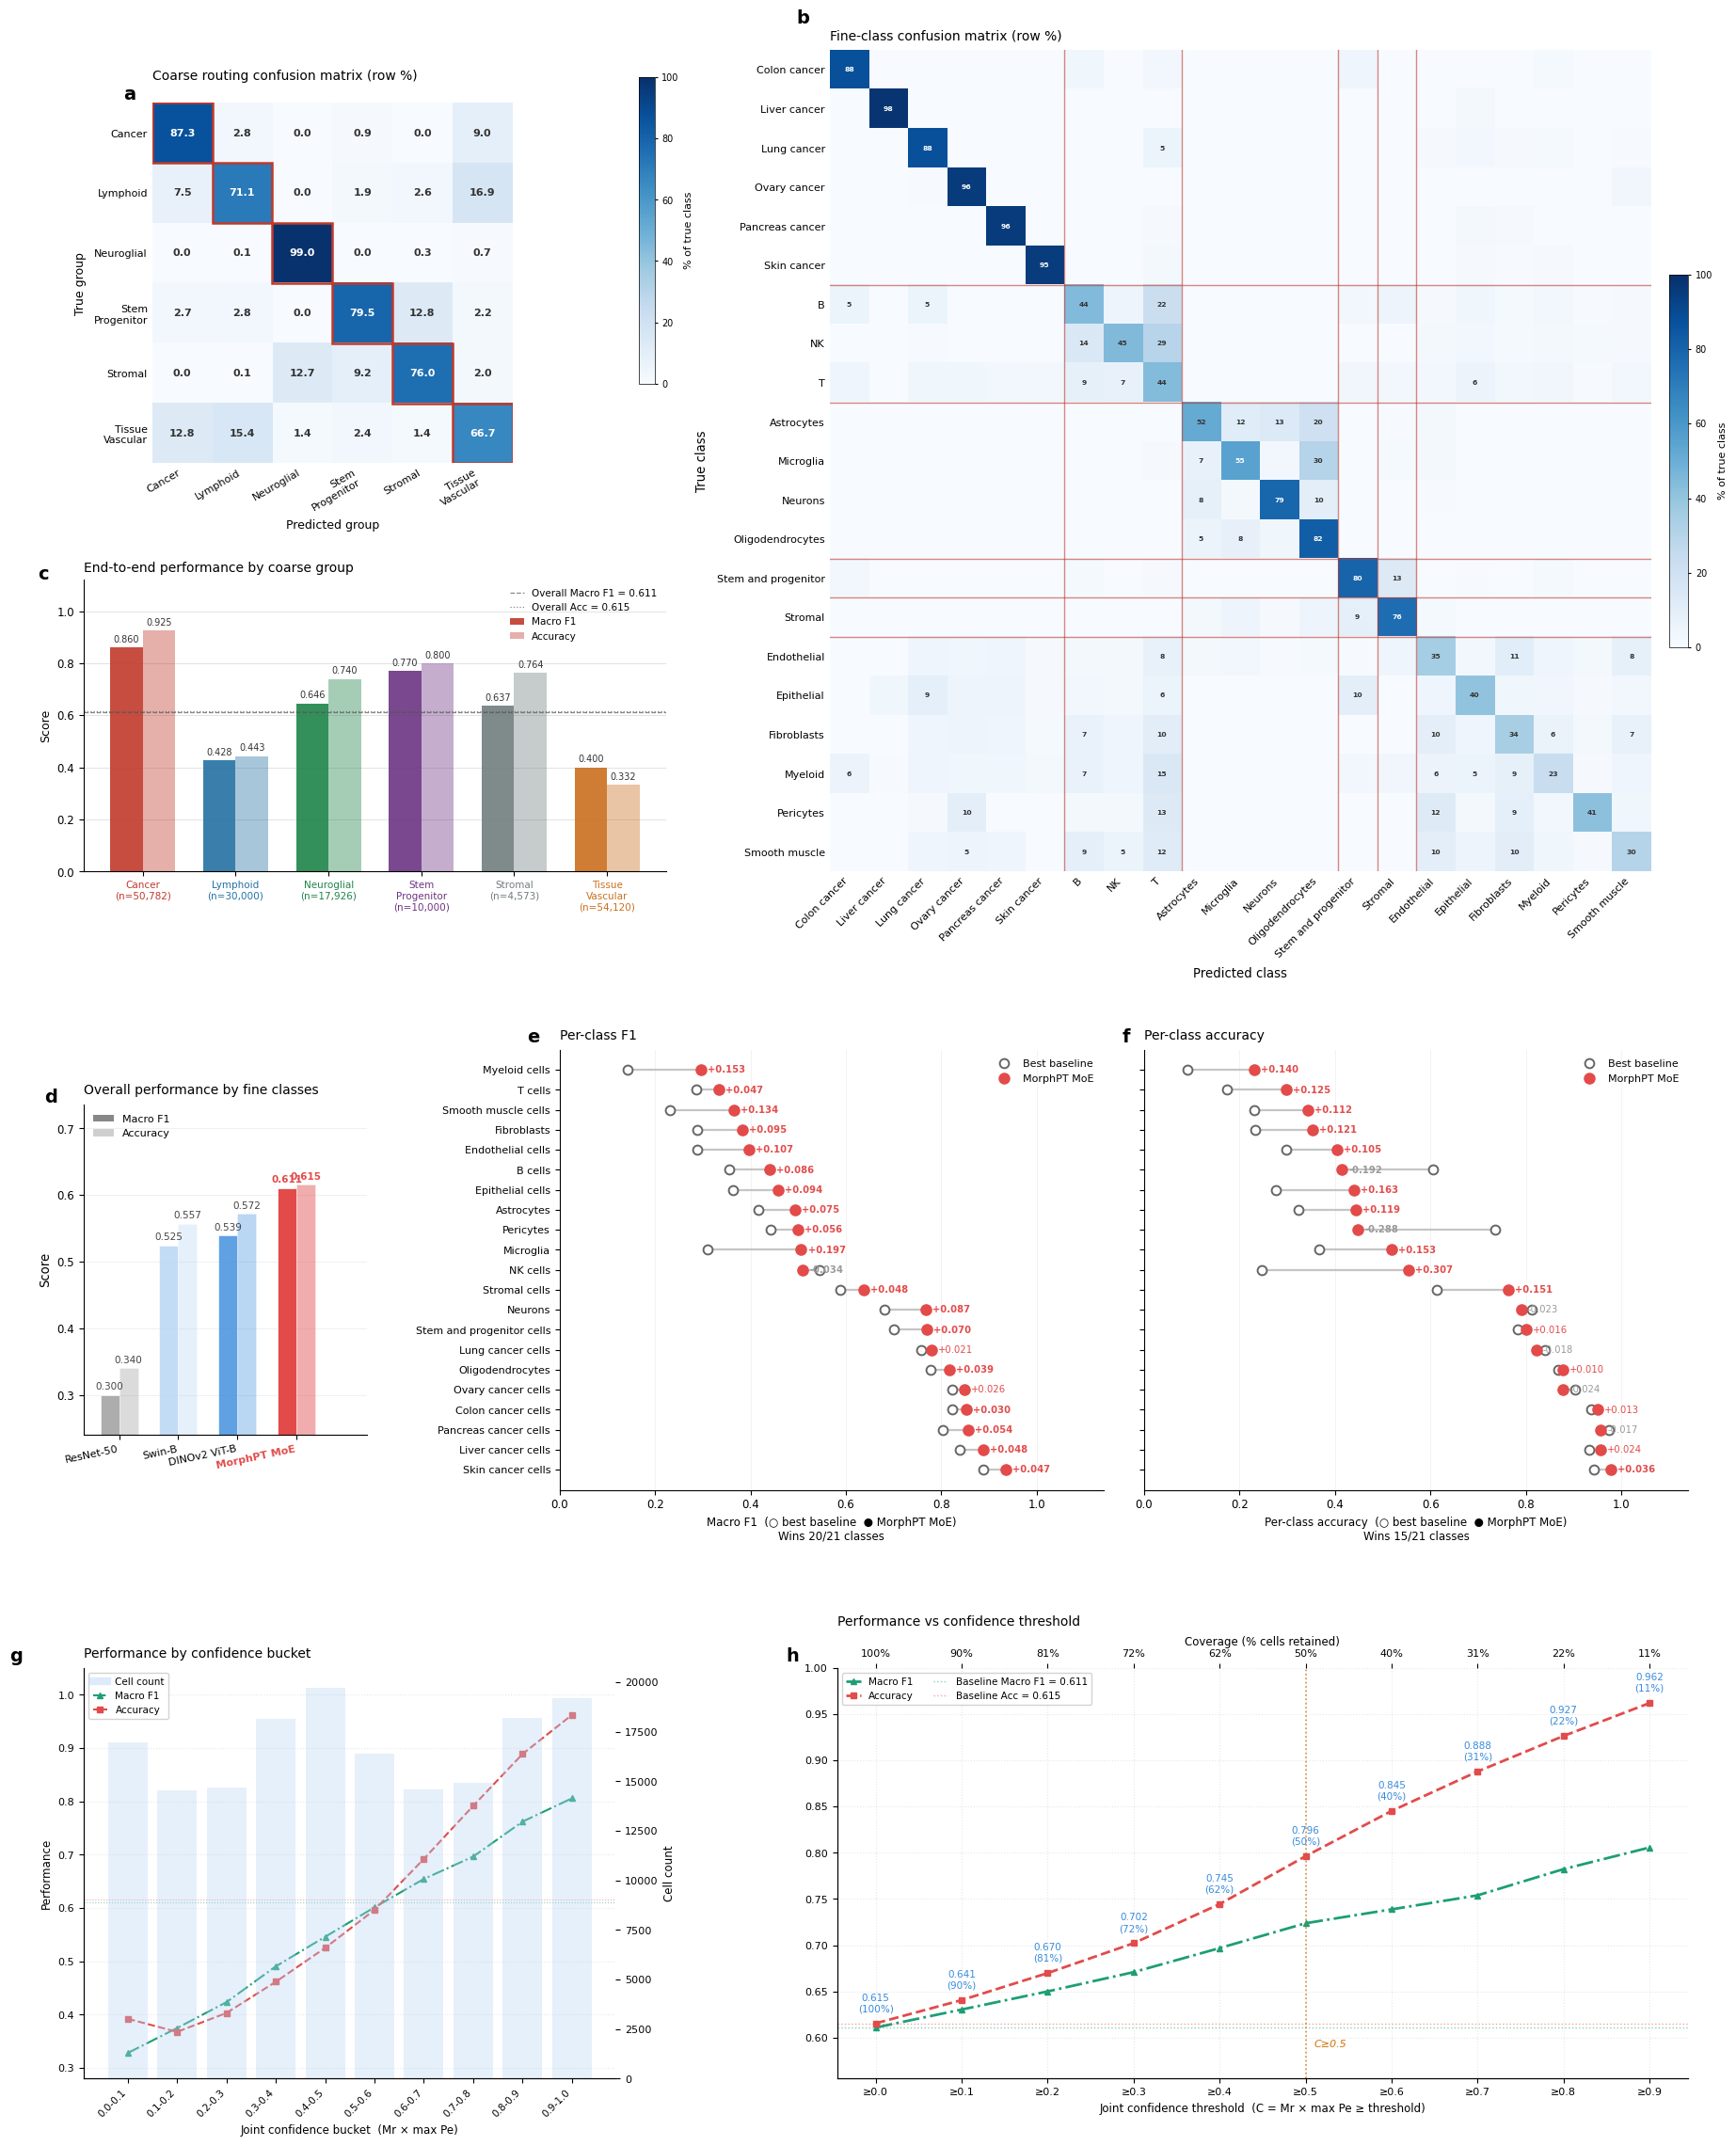

Done.


In [14]:
#!/usr/bin/env python3
"""
Combined panel figure — 3 rows
================================
Row 1 — Confusion (2 cols):
  Left col (stacked): a = coarse CM (top), c = coarse bar (bottom)
  Right col (full):   b = 21×21 fine CM

Row 2 — Performance (3 cols):
  d = combined F1 + BalAcc bar
  e = per-class F1 dumbbell
  f = per-class Accuracy dumbbell

Row 3 — Confidence (2 cols):
  g = joint confidence bucket bar chart
  h = performance vs threshold sweep

Usage: python fig_combined.py
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from pathlib import Path

# ── Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "axes.titlesize":     10,
    "axes.labelsize":     9.5,
    "xtick.labelsize":    8.5,
    "ytick.labelsize":    8.5,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
})

# ── Paths ─────────────────────────────────────────────────────────────────
BASE       = Path("/hpc/group/jilab/rz179/MorphPT_MOE/experiments")
MOE_RESULT = Path(
    "/hpc/group/jilab/rz179/MorphPT_MOE/results/"
    "moe_e2e_nobreast_6clusters_filtered_v3_with_expert_margin_with_gate_2_5x"
)

MODEL_PATHS = {
    "ResNet-50":    BASE / "baseline_resnet50_freeze_2p5x"                  / "per_class.json",
    "Swin-B":       BASE / "baseline_swin_base_patch4_window7_224_2p5x"     / "per_class.json",
    "DINOv2 ViT-B": BASE / "baseline_vit_base_patch16_dinov3.lvd1689m_2p5x" / "per_class.json",
    "MorphPT MoE":  MOE_RESULT / "per_class_soft.json",
}

MODEL_COLORS = {
    "ResNet-50":    "#999999",
    "Swin-B":       "#B5D4F4",
    "DINOv2 ViT-B": "#378ADD",
    "MorphPT MoE":  "#E24B4A",
}

MOE_KEY  = "MorphPT MoE"
BL_EDGE  = "#666666"
LINE_COL = "#BBBBBB"

MARGIN_COL = "router_x_maxpe"
PRED_COL   = "pred_soft"
N_STEPS    = 200

# Confidence colors
C_BAL = "#378ADD"
C_F1  = "#1D9E75"
C_ACC = "#E24B4A"
C_BAR = "#B5D4F4"
C_THR = "#D4700A"

# ── Taxonomy ──────────────────────────────────────────────────────────────
FINE_TO_COARSE = {
    "Colon cancer cells":        "Cancer",
    "Liver cancer cells":        "Cancer",
    "Lung cancer cells":         "Cancer",
    "Ovary cancer cells":        "Cancer",
    "Pancreas cancer cells":     "Cancer",
    "Skin cancer cells":         "Cancer",
    "B cells":                   "Lymphoid",
    "NK cells":                  "Lymphoid",
    "T cells":                   "Lymphoid",
    "Astrocytes":                "Neuroglial",
    "Microglia":                 "Neuroglial",
    "Neurons":                   "Neuroglial",
    "Oligodendrocytes":          "Neuroglial",
    "Endothelial cells":         "Tissue_Vascular",
    "Epithelial cells":          "Tissue_Vascular",
    "Fibroblasts":               "Tissue_Vascular",
    "Myeloid cells":             "Tissue_Vascular",
    "Pericytes":                 "Tissue_Vascular",
    "Smooth muscle cells":       "Tissue_Vascular",
    "Stem and progenitor cells": "Stem_Progenitor",
    "Stromal cells":             "Stromal",
}

COARSE_ORDER = [
    "Cancer", "Lymphoid", "Neuroglial",
    "Stem_Progenitor", "Stromal", "Tissue_Vascular",
]

COARSE_COLORS = {
    "Cancer":          "#C0392B",
    "Lymphoid":        "#2471A3",
    "Neuroglial":      "#1E8449",
    "Tissue_Vascular": "#CA6F1E",
    "Stem_Progenitor": "#6C3483",
    "Stromal":         "#717D7E",
}

OVERALL_ROUTER_BAL = 0.80
OVERALL_E2E_MF1    = 0.6109
OVERALL_E2E_BAL    = 0.6294


# ═══════════════════════════════════════════════════════════════════════════
# Load all data
# ═══════════════════════════════════════════════════════════════════════════
def load_per_class(path):
    rows = json.loads(Path(path).read_text())
    return {r["class"]: r for r in rows}

print("Loading performance data...")
RESULTS = {}
for model, path in MODEL_PATHS.items():
    p = Path(path)
    if not p.exists():
        print(f"  WARNING: {p} not found")
        continue
    RESULTS[model] = load_per_class(p)
    print(f"  Loaded {model}: {len(RESULTS[model])} classes")

models      = list(RESULTS.keys())
bl_models   = [m for m in models if m != MOE_KEY]
all_classes = sorted(RESULTS[models[0]].keys())

def get_metric(model, cls, metric):
    return RESULTS.get(model, {}).get(cls, {}).get(metric, 0.0)

def global_mean(model, metric):
    vals = [get_metric(model, c, metric) for c in all_classes
            if get_metric(model, c, "n") > 0]
    return float(np.mean(vals)) if vals else 0.0

def global_acc(model):
    total_n  = sum(get_metric(model, c, "n") for c in all_classes)
    total_tp = sum(
        round(get_metric(model, c, "rec") * get_metric(model, c, "n"))
        for c in all_classes
    )
    return total_tp / total_n if total_n > 0 else 0.0

print("Loading confusion data...")
cm_json     = json.loads((MOE_RESULT / "confusion_matrix_soft.json").read_text())
json_names  = cm_json["class_names"]
cm21_raw    = np.array(cm_json["matrix"], dtype=np.int64)
json_to_idx = {c: i for i, c in enumerate(json_names)}

sorted_fine = []
for coarse in COARSE_ORDER:
    sorted_fine += sorted(c for c in json_names
                          if FINE_TO_COARSE.get(c) == coarse)

sort_idx  = [json_to_idx[c] for c in sorted_fine]
cm21_sort = cm21_raw[np.ix_(sort_idx, sort_idx)]
cm21_pct  = 100 * cm21_sort / cm21_sort.sum(axis=1, keepdims=True).clip(min=1)
n_fine    = len(sorted_fine)

boundaries = []
pos = 0
for coarse in COARSE_ORDER:
    pos += sum(1 for c in sorted_fine if FINE_TO_COARSE.get(c) == coarse)
    boundaries.append(pos)

print("Loading predictions parquet...")
df        = pd.read_parquet(MOE_RESULT / "predictions.parquet")
n_coarse  = len(COARSE_ORDER)
c_to_idx  = {c: i for i, c in enumerate(COARSE_ORDER)}

cm6 = np.zeros((n_coarse, n_coarse), dtype=np.int64)
for t, p in zip(df["coarse_label"].values, df["router_pred"].values):
    ti, pi = c_to_idx.get(t, -1), c_to_idx.get(p, -1)
    if ti >= 0 and pi >= 0:
        cm6[ti, pi] += 1
cm6_pct = 100 * cm6 / cm6.sum(axis=1, keepdims=True).clip(min=1)

pc_rows    = json.loads((MOE_RESULT / "per_class_soft.json").read_text())
pc_by_name = {r["class"]: r for r in pc_rows}

coarse_rows = []
for coarse in COARSE_ORDER:
    fines   = [c for c in sorted_fine if FINE_TO_COARSE.get(c) == coarse]
    f1s     = [pc_by_name[c]["f1"]  for c in fines if c in pc_by_name]
    recs    = [pc_by_name[c]["rec"] for c in fines if c in pc_by_name]
    n_cells = int(sum(pc_by_name[c].get("n", 0) for c in fines if c in pc_by_name))
    # accuracy = weighted sum of per-class recall (tp/total_n)
    total_tp = sum(
        round(pc_by_name[c]["rec"] * pc_by_name[c]["n"])
        for c in fines if c in pc_by_name
    )
    acc_val = total_tp / n_cells if n_cells > 0 else 0.0
    coarse_rows.append({
        "coarse":   coarse,
        "n_cells":  n_cells,
        "macro_f1": round(float(np.mean(f1s)),  4) if f1s  else 0.0,
        "bal_acc":  round(float(np.mean(recs)), 4) if recs else 0.0,
        "acc":      round(acc_val, 4),
    })
df_coarse = pd.DataFrame(coarse_rows)

# Confidence metrics
all_cls_conf = sorted(df["label"].unique())
N            = len(df)

def compute_conf_metrics(y_true, y_pred):
    n2i = {n: i for i, n in enumerate(all_cls_conf)}
    ti  = np.array([n2i.get(y, -1) for y in y_true])
    pi  = np.array([n2i.get(y, -1) for y in y_pred])
    rows = []
    for i in range(len(all_cls_conf)):
        tp = int(((ti==i)&(pi==i)).sum())
        fn = int(((ti==i)&(pi!=i)).sum())
        fp = int(((ti!=i)&(pi==i)).sum())
        n  = tp + fn
        if n == 0: continue
        prec = tp / max(tp+fp, 1)
        rec  = tp / max(tp+fn, 1)
        f1   = 2*prec*rec / max(prec+rec, 1e-12)
        rows.append({"rec": rec, "f1": f1})
    bal = float(np.mean([r["rec"] for r in rows]))
    mf1 = float(np.mean([r["f1"]  for r in rows]))
    acc = float((ti==pi).sum()) / max(len(ti), 1)
    return bal, mf1, acc

base_bal, base_mf1, base_acc = compute_conf_metrics(
    df["label"].values, df[PRED_COL].values
)

# Bucket data
buckets = [(i/10, (i+1)/10) for i in range(10)]
bin_labels, cells, baccs, macros, accs = [], [], [], [], []
for lo, hi in buckets:
    mask   = (df[MARGIN_COL] >= lo) & (df[MARGIN_COL] < hi)
    subset = df[mask]
    if len(subset) == 0: continue
    bal, mf1, acc = compute_conf_metrics(
        subset["label"].values, subset[PRED_COL].values)
    bin_labels.append("{:.1f}-{:.1f}".format(lo, hi))
    cells.append(len(subset))
    baccs.append(bal); macros.append(mf1); accs.append(acc)

# Discrete threshold sweep
thresholds_disc = np.arange(0.0, 1.0, 0.1)
disc_thr, disc_bal, disc_f1, disc_acc, disc_cov = [], [], [], [], []
for t in thresholds_disc:
    subset = df[df[MARGIN_COL] >= t]
    if len(subset) < 50: break
    bal, mf1, acc = compute_conf_metrics(
        subset["label"].values, subset[PRED_COL].values)
    disc_thr.append(t); disc_bal.append(bal)
    disc_f1.append(mf1); disc_acc.append(acc)
    disc_cov.append(100 * len(subset) / N)
disc_thr = np.array(disc_thr); disc_bal = np.array(disc_bal)
disc_f1  = np.array(disc_f1);  disc_acc = np.array(disc_acc)
disc_cov = np.array(disc_cov)

print("All data loaded.")


# ═══════════════════════════════════════════════════════════════════════════
# Figure layout
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 28))

outer = gridspec.GridSpec(
    3, 1,
    figure=fig,
    height_ratios=[1.4, 0.75, 0.7],
    hspace=0.32,
)

# ── Row 1: confusion ──────────────────────────────────────────────────────
row1 = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=outer[0],
    width_ratios=[1, 1.6],
    wspace=0.12,
)

# Left col: a (coarse CM) + c (coarse bar) stacked
left_gs = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=row1[0],
    hspace=0.52,
    height_ratios=[1.05, 0.85],
)
ax_a = fig.add_subplot(left_gs[0])   # a: coarse CM
ax_c = fig.add_subplot(left_gs[1])   # c: coarse bar

# Right col: b (fine CM, large)
ax_b = fig.add_subplot(row1[1])      # b: 21×21 fine CM

# ── Row 2: performance ────────────────────────────────────────────────────

row2 = gridspec.GridSpecFromSubplotSpec(
    1, 3,
    subplot_spec=outer[1],
    width_ratios=[1.2, 1.5, 1.5],
    wspace=0.08,
)

ax_d = fig.add_subplot(row2[0])   # d: combined bar
ax_e = fig.add_subplot(row2[1])   # e: F1 dumbbell
ax_f = fig.add_subplot(row2[2])   # f: Acc dumbbell

# ── Row 3: confidence ─────────────────────────────────────────────────────
row3 = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=outer[2],
    width_ratios=[1, 1.6],
    wspace=0.32,
)
ax_g = fig.add_subplot(row3[0])   # g: bucket bar
ax_h = fig.add_subplot(row3[1])   # h: threshold sweep

# Panel labels
panel_axes  = [ax_a, ax_b, ax_c, ax_d, ax_e, ax_f, ax_g, ax_h]
panel_lbls  = ["a",  "b",  "c",  "d",  "e",  "f",  "g",  "h"]
panel_xoffs = [-0.08, -0.04, -0.08, -0.14, -0.06, -0.04, -0.14, -0.06]
for ax, lbl, xoff in zip(panel_axes, panel_lbls, panel_xoffs):
    ax.text(xoff, 1.05, lbl, transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top")


# ═══════════════════════════════════════════════════════════════════════════
# Panel a — 6×6 coarse routing confusion matrix
# ═══════════════════════════════════════════════════════════════════════════
im6 = ax_a.imshow(cm6_pct, cmap="Blues", vmin=0, vmax=100,
                  aspect="equal", interpolation="nearest")
cb6 = plt.colorbar(im6, ax=ax_a, fraction=0.046, pad=0.04, shrink=0.85)
cb6.set_label("% of true class", fontsize=8, labelpad=4)
cb6.ax.tick_params(labelsize=7, length=2)
cb6.outline.set_linewidth(0.5)

clabels = [c.replace("_", "\n") for c in COARSE_ORDER]
ax_a.set_xticks(range(n_coarse))
ax_a.set_yticks(range(n_coarse))
ax_a.set_xticklabels(clabels, rotation=30, ha="right", fontsize=8)
ax_a.set_yticklabels(clabels, fontsize=8)

for i in range(n_coarse):
    for j in range(n_coarse):
        v = cm6_pct[i, j]
        ax_a.text(j, i, "{:.1f}".format(v),
                  ha="center", va="center", fontsize=8,
                  color="white" if v > 55 else "#333333",
                  fontweight="bold")
for k in range(n_coarse):
    ax_a.add_patch(plt.Rectangle(
        (k-0.5, k-0.5), 1, 1,
        fill=False, edgecolor="#C0392B", linewidth=1.8, zorder=3))

for spine in ax_a.spines.values(): spine.set_visible(False)
ax_a.tick_params(length=0)
ax_a.set_xlabel("Predicted group", fontsize=9, labelpad=5)
ax_a.set_ylabel("True group", fontsize=9, labelpad=5)
ax_a.set_title(
    "Coarse routing confusion matrix (row %)\n",
    fontsize=10, pad=6, loc="left")


# ═══════════════════════════════════════════════════════════════════════════
# Panel b — 21×21 fine confusion matrix
# ═══════════════════════════════════════════════════════════════════════════
im21 = ax_b.imshow(cm21_pct, cmap="Blues", vmin=0, vmax=100,
                   aspect="equal", interpolation="nearest")
cb21 = plt.colorbar(im21, ax=ax_b, fraction=0.020, pad=0.02, shrink=0.82)
cb21.set_label("% of true class", fontsize=8, labelpad=4)
cb21.ax.tick_params(labelsize=7, length=2)
cb21.outline.set_linewidth(0.5)

short_labels = [c.replace(" cells", "").replace(" cancer cells", "\ncancer")
                for c in sorted_fine]
ax_b.set_xticks(range(n_fine))
ax_b.set_yticks(range(n_fine))
ax_b.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
ax_b.set_yticklabels(short_labels, fontsize=8)

for i in range(n_fine):
    for j in range(n_fine):
        v = cm21_pct[i, j]
        if v > 5:
            ax_b.text(j, i, "{:.0f}".format(v),
                      ha="center", va="center", fontsize=5.5,
                      color="white" if v > 55 else "#333333",
                      fontweight="bold")

for b in boundaries[:-1]:
    ax_b.axhline(b-0.5, color="#C0392B", linewidth=1.0, alpha=0.6)
    ax_b.axvline(b-0.5, color="#C0392B", linewidth=1.0, alpha=0.6)

for spine in ax_b.spines.values(): spine.set_visible(False)
ax_b.tick_params(length=0)
ax_b.set_xlabel("Predicted class", fontsize=9.5, labelpad=6)
ax_b.set_ylabel("True class", fontsize=9.5, labelpad=6)
ax_b.set_title("Fine-class confusion matrix (row %)", fontsize=10,
               pad=8, loc="left")


# ═══════════════════════════════════════════════════════════════════════════
# Panel c — Coarse-group bar chart
# ═══════════════════════════════════════════════════════════════════════════
x_pos  = np.arange(n_coarse)
width  = 0.35
colors = [COARSE_COLORS[c] for c in COARSE_ORDER]

overall_coarse_f1  = global_mean(MOE_KEY, "f1")
overall_coarse_acc = global_acc(MOE_KEY)

bars_f1  = ax_c.bar(x_pos - width/2, df_coarse["macro_f1"], width,
                    color=colors, alpha=0.90, label="Macro F1", linewidth=0)
bars_bal = ax_c.bar(x_pos + width/2, df_coarse["acc"], width,
                    color=colors, alpha=0.40, label="Accuracy", linewidth=0)

for bar in list(bars_f1) + list(bars_bal):
    h = bar.get_height()
    ax_c.text(bar.get_x() + bar.get_width()/2, h + 0.013,
              "{:.3f}".format(h),
              ha="center", va="bottom", fontsize=7, color="#333333")

ax_c.axhline(overall_coarse_f1, color="#555555", linestyle="--",
             linewidth=0.9, alpha=0.7,
             label="Overall Macro F1 = {:.3f}".format(overall_coarse_f1))
ax_c.axhline(overall_coarse_acc, color="#555555", linestyle=":",
             linewidth=0.9, alpha=0.7,
             label="Overall Acc = {:.3f}".format(overall_coarse_acc))

bar_xlabels = [
    "{}\n(n={:,})".format(r["coarse"].replace("_", "\n"), r["n_cells"])
    for _, r in df_coarse.iterrows()
]
ax_c.set_xticks(x_pos)
ax_c.set_xticklabels(bar_xlabels, fontsize=7.5)
for tick, coarse in zip(ax_c.get_xticklabels(), COARSE_ORDER):
    tick.set_color(COARSE_COLORS[coarse])

ax_c.set_ylim(0, 1.12)
ax_c.set_ylabel("Score", fontsize=9)
ax_c.set_title("End-to-end performance by coarse group",
               fontsize=10, pad=6, loc="left")
ax_c.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax_c.grid(axis="y", color="#DDDDDD", linewidth=0.6, zorder=0)
ax_c.set_axisbelow(True)
ax_c.legend(fontsize=7.5, loc="upper right", frameon=False, handlelength=1.4)


# ═══════════════════════════════════════════════════════════════════════════
# Panel d — Combined F1 + Acc bar
# ═══════════════════════════════════════════════════════════════════════════
f1_vals  = [global_mean(m, "f1") for m in models]
acc_vals = [global_acc(m)        for m in models]
xs = np.arange(len(models))
bw = 0.32

for i, m in enumerate(models):
    color = MODEL_COLORS[m]
    ax_d.bar(xs[i] - bw/2, f1_vals[i], bw,
             color=color, alpha=1.0 if m == MOE_KEY else 0.80,
             edgecolor="white", linewidth=0.5)
    ax_d.bar(xs[i] + bw/2, acc_vals[i], bw,
             color=color, alpha=0.45 if m == MOE_KEY else 0.35,
             edgecolor="white", linewidth=0.5)
    ax_d.text(xs[i] - bw/2, f1_vals[i] + 0.005,
              "{:.3f}".format(f1_vals[i]),
              ha="center", va="bottom", fontsize=7.5,
              color=color if m == MOE_KEY else "#444444",
              fontweight="bold" if m == MOE_KEY else "normal")
    ax_d.text(xs[i] + bw/2, acc_vals[i] + 0.005,
              "{:.3f}".format(acc_vals[i]),
              ha="center", va="bottom", fontsize=7.5,
              color=color if m == MOE_KEY else "#444444",
              fontweight="bold" if m == MOE_KEY else "normal")

moe_i    = models.index(MOE_KEY)
best_f1  = max(global_mean(m, "f1") for m in bl_models)
best_acc = max(global_acc(m)        for m in bl_models)
moe_f1   = global_mean(MOE_KEY, "f1")
moe_acc  = global_acc(MOE_KEY)

# +Δ labels to the right of MorphPT bars
#ax_d.text(moe_i + bw + 0.10, moe_f1, "{:+.3f}".format(moe_f1 - best_f1), va="center", ha="left", fontsize=8.5, color="#E24B4A", fontweight="bold")
#ax_d.text(moe_i + bw + 0.10, moe_acc, "{:+.3f}".format(moe_acc - best_acc), va="center", ha="left", fontsize=8.5, color="#E24B4A", fontweight="bold")

ax_d.set_xticks(xs)
ax_d.set_xticklabels(models, fontsize=8, rotation=12, ha="right")
ax_d.get_xticklabels()[moe_i].set_color("#E24B4A")
ax_d.get_xticklabels()[moe_i].set_fontweight("bold")
y_floor = min(f1_vals + acc_vals) - 0.06
ax_d.set_ylim(max(0, y_floor), min(1.0, max(f1_vals + acc_vals) + 0.12))
ax_d.set_xlim(-0.6, len(models) + 0.2)
ax_d.set_ylabel("Score", fontsize=9.5)
ax_d.set_title("Overall performance by fine classes", fontsize=10, pad=8, loc="left")
ax_d.grid(axis="y", color="#EEEEEE", linewidth=0.6, zorder=0)
ax_d.set_axisbelow(True)
ax_d.legend(handles=[
    mpatches.Patch(facecolor="#888888", alpha=1.0,  label="Macro F1"),
    mpatches.Patch(facecolor="#888888", alpha=0.40, label="Accuracy"),
], fontsize=8, loc="upper left", frameon=False)


# ═══════════════════════════════════════════════════════════════════════════
# Dumbbell helper
# ═══════════════════════════════════════════════════════════════════════════
def draw_dumbbell(ax, metric, xlabel, title, hide_ylabels=False):
    cls_data = []
    for cls in all_classes:
        moe_val  = get_metric(MOE_KEY, cls, metric)
        best_val = max(get_metric(m, cls, metric) for m in bl_models)
        cls_data.append({
            "cls": cls, "moe": moe_val,
            "best_bl": best_val, "delta": moe_val - best_val,
        })
    cls_data.sort(key=lambda d: d["moe"])
    nc = len(cls_data)

    for i, d in enumerate(cls_data):
        lo = min(d["best_bl"], d["moe"])
        hi = max(d["best_bl"], d["moe"])
        ax.plot([lo, hi], [i, i], color=LINE_COL,
                linewidth=1.6, alpha=0.85, zorder=1,
                solid_capstyle="round")
        ax.scatter(d["best_bl"], i, s=50, zorder=3,
                   facecolors="white", edgecolors=BL_EDGE, linewidths=1.4)
        ax.scatter(d["moe"], i, s=65, zorder=4,
                   facecolors=MODEL_COLORS[MOE_KEY],
                   edgecolors=MODEL_COLORS[MOE_KEY])
        sign = "+" if d["delta"] >= 0 else ""
        ax.text(d["moe"] + 0.014, i,
                "{}{:.3f}".format(sign, d["delta"]),
                va="center", ha="left", fontsize=7.2,
                color="#E24B4A" if d["delta"] >= 0 else "#999999",
                fontweight="bold" if abs(d["delta"]) > 0.03 else "normal")

    if hide_ylabels:
        ax.set_yticks(range(nc))
        ax.set_yticklabels([])
    else:
        ax.set_yticks(range(nc))
        ax.set_yticklabels([d["cls"] for d in cls_data],
                           fontsize=8, color="black")
    ax.invert_yaxis()

    n_pos  = sum(1 for d in cls_data if d["delta"] > 0)
    mean_d = np.mean([d["delta"] for d in cls_data])
    ax.set_xlabel(
        "{}\nWins {}/{} classes".format(
            xlabel, n_pos, nc),
        fontsize=8.5)
    ax.set_xlim(0, 1.14)
    ax.set_title(title, fontsize=10, pad=8, loc="left")
    ax.grid(axis="x", color="#EEEEEE", linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(handles=[
        mlines.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor="white", markeredgecolor=BL_EDGE,
                      markersize=7, markeredgewidth=1.4,
                      label="Best baseline"),
        mlines.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=MODEL_COLORS[MOE_KEY],
                      markeredgecolor=MODEL_COLORS[MOE_KEY],
                      markersize=8, label="MorphPT MoE"),
    ], fontsize=8, loc="upper right", frameon=False)


# ═══════════════════════════════════════════════════════════════════════════
# Panel e — F1 dumbbell
# ═══════════════════════════════════════════════════════════════════════════
draw_dumbbell(ax_e, "f1",
              xlabel="Macro F1  (○ best baseline  ● MorphPT MoE)",
              title="Per-class F1")

# ═══════════════════════════════════════════════════════════════════════════
# Panel f — Accuracy dumbbell
# ═══════════════════════════════════════════════════════════════════════════
draw_dumbbell(ax_f, "rec",
              xlabel="Per-class accuracy  (○ best baseline  ● MorphPT MoE)",
              title="Per-class accuracy",
              hide_ylabels=True)


# ═══════════════════════════════════════════════════════════════════════════
# Panel g — Joint confidence bucket bar chart
# ═══════════════════════════════════════════════════════════════════════════
ax_g2 = ax_g.twinx()

# Performance lines on LEFT axis (ax_g)
#ax_g.plot(range(len(bin_labels)), baccs, color=C_BAL, marker="o", markersize=4, linewidth=1.5,label="Balanced Acc")
ax_g.plot(range(len(bin_labels)), macros,
          color=C_F1, marker="^", markersize=4, linewidth=1.5,
          linestyle="-.", label="Macro F1")
ax_g.plot(range(len(bin_labels)), accs,
          color=C_ACC, marker="s", markersize=4, linewidth=1.5,
          linestyle="--", label="Accuracy")

#ax_g.axhline(base_bal, color=C_BAL, linestyle=":", linewidth=0.8, alpha=0.5)
ax_g.axhline(base_mf1, color=C_F1,  linestyle=":", linewidth=0.8, alpha=0.5)
ax_g.axhline(base_acc, color=C_ACC, linestyle=":", linewidth=0.8, alpha=0.5)

# Cell count bars on RIGHT axis (ax_g2)
ax_g2.bar(range(len(bin_labels)), cells,
          color=C_BAR, alpha=0.35, zorder=1)

ax_g.set_xticks(range(len(bin_labels)))
ax_g.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=7.5)
ax_g.set_xlabel("Joint confidence bucket  (Mr × max Pe)", fontsize=8.5)
ax_g.set_ylabel("Performance", fontsize=8.5)
ax_g2.set_ylabel("Cell count", fontsize=8.5)
ax_g.set_ylim(0.28, 1.05)
ax_g.tick_params(axis="y", labelsize=8)
ax_g2.tick_params(labelsize=8)
ax_g.grid(axis="y", linestyle=":", alpha=0.3, zorder=0)
ax_g.set_title("Performance by confidence bucket", fontsize=10,
               pad=8, loc="left")

legend_handles = [
    Line2D([0],[0], color=C_BAR, linewidth=6, alpha=0.45, label="Cell count"),
    #Line2D([0],[0], color=C_BAL, linewidth=1.5, marker="o", markersize=4, label="Balanced Acc"),
    Line2D([0],[0], color=C_F1,  linewidth=1.5, marker="^", markersize=4,
           linestyle="-.", label="Macro F1"),
    Line2D([0],[0], color=C_ACC, linewidth=1.5, marker="s", markersize=4,
           linestyle="--", label="Accuracy"),
]
ax_g.legend(handles=legend_handles, fontsize=7.5, loc="upper left",
            framealpha=0.85, handlelength=1.5)


# ═══════════════════════════════════════════════════════════════════════════
# Panel h — Performance vs threshold sweep
# ═══════════════════════════════════════════════════════════════════════════
#ax_h.plot(disc_thr, disc_bal, color=C_BAL, marker="o", markersize=5, linewidth=2.0, label="Balanced Acc")
ax_h.plot(disc_thr, disc_f1,  color=C_F1,  marker="^", markersize=5,
          linewidth=2.0, linestyle="-.", label="Macro F1")
ax_h.plot(disc_thr, disc_acc, color=C_ACC, marker="s", markersize=5,
          linewidth=2.0, linestyle="--", label="Accuracy")

for t, b, c in zip(disc_thr, disc_acc, disc_cov):
    ax_h.annotate("{:.3f}\n({:.0f}%)".format(b, c),
                  (t, b), textcoords="offset points",
                  xytext=(0, 9), ha="center", fontsize=7.5,
                  color=C_BAL)

#ax_h.axhline(base_bal, color=C_BAL, linestyle=":", linewidth=1.0, alpha=0.5, label="Baseline Bal Acc = {:.3f}".format(base_bal))
ax_h.axhline(base_mf1, color=C_F1,  linestyle=":", linewidth=1.0, alpha=0.5,
             label="Baseline Macro F1 = {:.3f}".format(base_mf1))
ax_h.axhline(base_acc, color=C_ACC, linestyle=":", linewidth=1.0, alpha=0.5,
             label="Baseline Acc = {:.3f}".format(base_acc))

ax_h.axvline(0.5, color=C_THR, linestyle=":", linewidth=1.2, alpha=0.8)
ax_h.text(0.51, base_bal - 0.04, "C≥0.5", fontsize=8,
          color=C_THR, style="italic")

ax_h.set_xlabel(
    "Joint confidence threshold  (C = Mr × max Pe ≥ threshold)",
    fontsize=8.5)
# y-label shared with panel g — omit to avoid repetition
ax_h.set_xticks(disc_thr)
ax_h.set_xticklabels(["≥{:.1f}".format(t) for t in disc_thr], fontsize=8)
ax_h.set_ylim(base_acc - 0.06, 1.0)
ax_h.tick_params(labelsize=8)
ax_h.grid(linestyle=":", alpha=0.3)
ax_h.legend(fontsize=7.5, loc="upper left", framealpha=0.85,
            ncol=2, handlelength=1.5)
ax_h.set_title("Performance vs confidence threshold", fontsize=10,
               pad=8, loc="left")

# Secondary x-axis: coverage %
ax_h2 = ax_h.twiny()
ax_h2.set_xlim(ax_h.get_xlim())
ax_h2.set_xticks(disc_thr)
ax_h2.set_xticklabels(["{:.0f}%".format(c) for c in disc_cov], fontsize=8)
ax_h2.set_xlabel("Coverage (% cells retained)", fontsize=8.5, labelpad=3)



fig.canvas.draw()
pos = ax_a.get_position()
ax_a.set_position([pos.x0 - 0.05, pos.y0 - 0.02, pos.width, pos.height])


pos = ax_d.get_position()
new_w = pos.width  * 0.65   # 宽度缩到 70%
new_h = pos.height * 0.75   # 高度缩到 75%
new_y = pos.y0 + (pos.height - new_h) / 2   # 垂直居中
ax_d.set_position([pos.x0, new_y, new_w, new_h])

# ── Save ──────────────────────────────────────────────────────────────────
for ext in ("pdf", "png"):
    dpi = 300 if ext == "pdf" else 150
    fig.savefig("fig_combined.{}".format(ext), format=ext,
                dpi=dpi, bbox_inches="tight")
    print("Saved: fig_combined.{}".format(ext))

plt.show()
print("Done.")

In [9]:
print("Total rows:", len(df))
print("Rows with margin >= 0:", (df["router_x_maxpe"] >= 0).sum())
print("NaN count:", df["router_x_maxpe"].isna().sum())
print("Negative count:", (df["router_x_maxpe"] < 0).sum())

Total rows: 167401
Rows with margin >= 0: 167401
NaN count: 0
Negative count: 0


In [10]:
print("disc_acc:", disc_acc[:3])
print("disc_bal:", disc_bal[:3])
print("base_acc:", base_acc)
print("base_bal:", base_bal)

disc_acc: [0.61546227 0.64061181 0.66984604]
disc_bal: [0.62937285 0.64681425 0.66526289]
base_acc: 0.6154622732241742
base_bal: 0.629372851520882
